# Vega 7a Full Public Goldset – Both Routes (subset-style report)
Same figures as `report_subset.ipynb`, but **one split**: full `7a_dicty_gold_llm_public` from `output/dicty_gold_build/7a_dicty_gold_llm_public.jsonl`.
Input workflow: `output/workflow_vega_7a_public_goldset_both_routes/{retrieval/bm25,retrieval/dense,retrieval/fusion,rerank/...,snippet/...}` (see `scripts/public/shared_scripts/docs/output.md`).

## 1. Imports and Setup

In [141]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

## 2. Load Data

In [122]:
base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    base_dir = base_dir.parent

print("Base dir:", base_dir)

workflow_dir = base_dir / "output" / "workflow_vega_7a_public_goldset_both_routes"
retrieval_dir = workflow_dir / "retrieval"
rerank_dir = workflow_dir / "rerank"
snippet_dir = workflow_dir / "snippet"

bm25_metrics = pd.read_csv(retrieval_dir / "bm25" / "metrics.csv")
dense_metrics = pd.read_csv(retrieval_dir / "dense" / "metrics.csv")
hybrid_metrics = pd.read_csv(retrieval_dir / "fusion" / "metrics.csv")

bm25_metrics = bm25_metrics.rename(columns={"batch": "split"})
dense_metrics = dense_metrics.rename(columns={"batch": "split"})

bm25_metrics["method"] = "BM25"
dense_metrics["method"] = "Dense"
hybrid_metrics["method"] = "BM25 Dense Fusion"

output_dir = workflow_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
# Consolidated paper figures land here; diagnostic plots stay under output_dir.
paper_figures_dir = base_dir / "output" / "paper_figures"
paper_figures_dir.mkdir(parents=True, exist_ok=True)

splits = ["7a_dicty_gold_llm_public"]
split_labels = {"7a_dicty_gold_llm_public": "7a full public"}
_N_SPLIT_COLS = len(splits)

qrels_paths = {
    "7a_dicty_gold_llm_public": base_dir / "output" / "dicty_gold_build" / "7a_dicty_gold_llm_public.jsonl",
}

print("Loaded BM25:", bm25_metrics.shape)
print("Loaded Dense:", dense_metrics.shape)
print("Loaded Hybrid:", hybrid_metrics.shape)

Base dir: /Users/yun/develop/dictycite
Loaded BM25: (1, 17)
Loaded Dense: (1, 17)
Loaded Hybrid: (6, 28)


In [123]:
# Helper: extract PMID from a PubMed URL or bare ID string
def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    if "/" in doc_entry:
        return doc_entry.rsplit("/", 1)[-1]
    return doc_entry


def _load_qrels(path: Path) -> dict[str, set[str]]:
    """Load gold qrels from a .jsonl file (one query record per line)."""
    qrels: dict[str, set[str]] = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            pmids = {_extract_pmid(d) for d in q.get("documents", []) if _extract_pmid(d)}
            if qid and pmids:
                qrels[qid] = pmids
    return qrels


qrels_by_split = {s: _load_qrels(p) for s, p in qrels_paths.items()}
n_per_split = {s: len(q) for s, q in qrels_by_split.items()}
print("Qrels loaded:", {s: n for s, n in n_per_split.items()})

# Single-split: drop redundant axis titles; put query count on suptitle and tighten top margin.
_N_PRIMARY: int | None = int(next(iter(n_per_split.values()))) if _N_SPLIT_COLS == 1 else None
_TIGHT_RECT = [0, 0, 1, 0.93] if _N_SPLIT_COLS <= 1 else [0, 0, 1, 0.96]


def _suptitle_n(title: str) -> str:
    return f"{title} (n={_N_PRIMARY})" if _N_PRIMARY is not None else title


def _axis_split_title(ax, split: str, *, fontsize: int = 15) -> None:
    if _N_SPLIT_COLS <= 1:
        return
    n_split = n_per_split.get(split, "?")
    ax.set_title(
        f"{split_labels.get(split, split)} (n={n_split})",
        fontsize=fontsize,
        fontweight="bold",
    )

Qrels loaded: {'7a_dicty_gold_llm_public': 1656}


## 3. Stage 1 Recall Curves (one panel per configured split)

Shared K values (plotted up to 2000): [10, 50, 100, 200, 300, 400, 500, 1000, 2000]
Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/01_stage1_recall_per_split.png


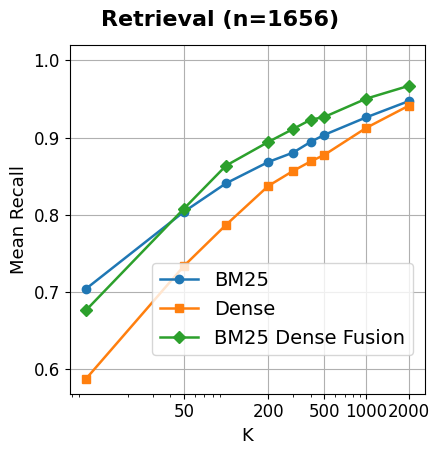

In [124]:
recall_cols_bm25 = sorted(
    [c for c in bm25_metrics.columns if c.startswith("MeanR@")],
    key=lambda c: int(c.split("@")[1]),
)
recall_cols_hybrid = sorted(
    [c for c in hybrid_metrics.columns if c.startswith("MeanR@")],
    key=lambda c: int(c.split("@")[1]),
)
recall_cols = sorted(
    set(recall_cols_bm25) & set(recall_cols_hybrid),
    key=lambda c: int(c.split("@")[1]),
)
recall_cols = [c for c in recall_cols if int(c.split("@")[1]) <= 2000]
k_values = [int(c.split("@")[1]) for c in recall_cols]

print("Shared K values (plotted up to 2000):", k_values)

tick_candidates = [50, 200, 500, 1000, 2000]
tick_values = [k for k in tick_candidates if k in k_values]

methods_cfg = {
    "BM25": {"df": bm25_metrics, "color": "#1f77b4", "marker": "o"},
    "Dense": {"df": dense_metrics, "color": "#ff7f0e", "marker": "s"},
    "BM25 Dense Fusion": {"df": hybrid_metrics, "color": "#2ca02c", "marker": "D"},
}

fig, axes = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

global_ymin, global_ymax = 1.0, 0.0
for split in splits:
    for cfg in methods_cfg.values():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols]
        global_ymin = min(global_ymin, min(vals))
        global_ymax = max(global_ymax, max(vals))

y_pad = (global_ymax - global_ymin) * 0.05
global_ymin = max(0, global_ymin - y_pad)
#global_ymax = min(1, global_ymax + y_pad)
global_ymax = 1.02

for idx, split in enumerate(splits):
    ax = axes[idx]
    for method_name, cfg in methods_cfg.items():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols]
        ax.plot(
            k_values,
            vals,
            marker=cfg["marker"],
            color=cfg["color"],
            label=method_name,
            markersize=6,
            linewidth=1.8,
        )

    _axis_split_title(ax, split)
    ax.set_ylim(global_ymin, global_ymax)

    if idx == 0:
        ax.set_ylabel("Mean Recall")
    else:
        ax.set_ylabel("")

    ax.set_xlabel("K")
    ax.set_xscale("log")
    ax.set_xticks(tick_values)
    ax.set_xticklabels([str(k) for k in tick_values], rotation=0)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.95, 0.19), fontsize=14)

fig.suptitle(_suptitle_n("Retrieval"), fontsize=16, fontweight="bold", y=0.9)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path = output_dir / "01_stage1_recall_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 4. Retrieval vs Rerank – Recall Curves (K ≤ 300)

Stage2+ K values (≤300): [10, 50, 100, 200, 300]
Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/02_hybrid_rerank_fusion_recall_per_split.png


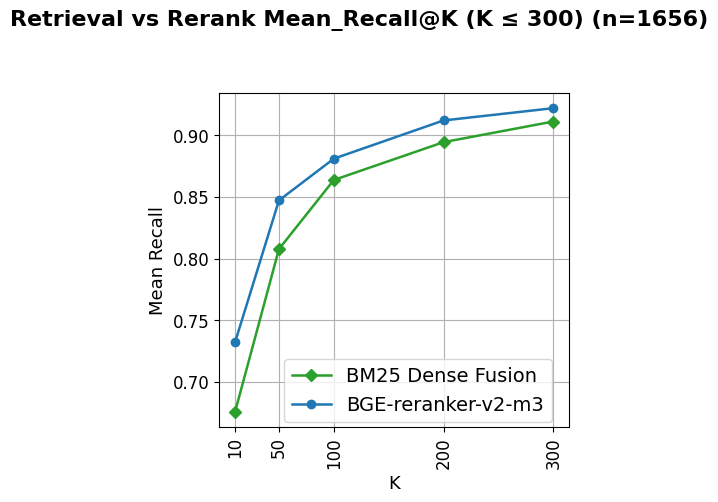

In [125]:
hybrid_stage1 = hybrid_metrics.copy()
rerank_metrics = pd.read_csv(rerank_dir / "cross_encoder" / "metrics.csv")
rerank_fusion_metrics = pd.read_csv(rerank_dir / "post_rerank_fusion_snippet" / "metrics.csv")

if "split" not in rerank_metrics.columns:
    if "label" in rerank_metrics.columns:
        rerank_metrics = rerank_metrics.rename(columns={"label": "split"})
    elif "batch" in rerank_metrics.columns:
        rerank_metrics = rerank_metrics.rename(columns={"batch": "split"})
if "split" not in rerank_fusion_metrics.columns and "batch" in rerank_fusion_metrics.columns:
    rerank_fusion_metrics = rerank_fusion_metrics.rename(columns={"batch": "split"})

methods_stage2 = {
    "BM25 Dense Fusion": {
        "df": hybrid_stage1,
        "color": "#2ca02c",
        "marker": "D",
    },
    "BGE-m3": {
        "df": rerank_metrics,
        "color": "#1f77b4",
        "marker": "o",
    },
}

recall_cols_all = []
for cfg in methods_stage2.values():
    cols = [c for c in cfg["df"].columns if c.startswith("MeanR@")]
    recall_cols_all.append(set(cols))

recall_cols_common = sorted(
    set.intersection(*recall_cols_all),
    key=lambda c: int(c.split("@")[1]),
)
k_vals_recall = [int(c.split("@")[1]) for c in recall_cols_common if 10 <= int(c.split("@")[1]) <= 300]
recall_cols_common = [f"MeanR@{k}" for k in k_vals_recall]

print("Stage2+ K values (≤300):", k_vals_recall)

fig, axes = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

global_ymin, global_ymax = 1.0, 0.0
for split in splits:
    for cfg in methods_stage2.values():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols_common]
        global_ymin = min(global_ymin, min(vals))
        global_ymax = max(global_ymax, max(vals))

y_pad = (global_ymax - global_ymin) * 0.05
global_ymin = max(0, global_ymin - y_pad)
global_ymax = min(1, global_ymax + y_pad)

tick_candidates_recall = [10, 50, 100, 200, 300]
tick_values_recall = [k for k in tick_candidates_recall if k in k_vals_recall]

for idx, split in enumerate(splits):
    ax = axes[idx]
    for method_name, cfg in methods_stage2.items():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols_common]
        ax.plot(
            k_vals_recall,
            vals,
            marker=cfg["marker"],
            color=cfg["color"],
            label=method_name,
            markersize=6,
            linewidth=1.8,
        )

    _axis_split_title(ax, split)
    ax.set_ylim(global_ymin, global_ymax)

    if idx == 0:
        ax.set_ylabel("Mean Recall")
    else:
        ax.set_ylabel("")

    ax.set_xlabel("K")
    ax.set_xticks(tick_values_recall)
    ax.set_xticklabels([str(k) for k in tick_values_recall], rotation=90)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=14)

fig.suptitle(_suptitle_n("Retrieval vs Rerank Mean_Recall@K (K ≤ 300)"), fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path = output_dir / "02_hybrid_rerank_fusion_recall_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 5. Retrieval vs Rerank vs Post-rerank Fusion – MAP@10 (Bar Plots)

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/03_hybrid_rerank_fusion_map10_bars_per_split.png


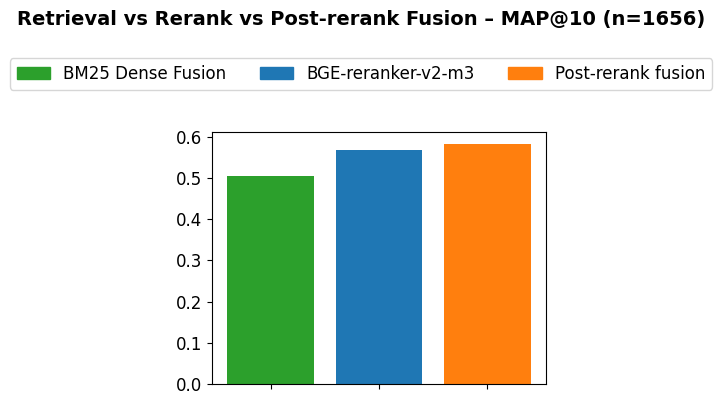

In [126]:
fig, axes_bar = plt.subplots(1, _N_SPLIT_COLS, figsize=(4 * _N_SPLIT_COLS, 4), sharey=True, squeeze=False)
axes_bar = axes_bar.ravel()

method_colors_bar = {
    "BM25 Dense Fusion": "#2ca02c",
    "BGE-m3": "#1f77b4",
    "Post-rerank fusion": "#ff7f0e",
}

for idx, split in enumerate(splits):
    cur_ax = axes_bar[idx]
    vals = []
    labels_methods = []

    row_h = hybrid_stage1[hybrid_stage1["split"] == split]
    if not row_h.empty:
        vals.append(float(row_h.iloc[0]["MAP@10"]))
        labels_methods.append("BM25 Dense Fusion")

    row_r = rerank_metrics[rerank_metrics["split"] == split]
    if not row_r.empty:
        vals.append(float(row_r.iloc[0]["MAP@10"]))
        labels_methods.append("BGE-m3")

    row_f = rerank_fusion_metrics[rerank_fusion_metrics["split"] == split]
    if not row_f.empty:
        vals.append(float(row_f.iloc[0]["MAP@10"]))
        labels_methods.append("Post-rerank fusion")

    x = np.arange(len(labels_methods))
    colors = [method_colors_bar[label] for label in labels_methods]
    cur_ax.bar(x, vals, color=colors)
    cur_ax.set_xticks(x)
    cur_ax.set_xticklabels("", rotation=30, ha="right")
    _axis_split_title(cur_ax, split, fontsize=13)

handles_bar = [
    plt.matplotlib.patches.Patch(color=method_colors_bar[m], label=m)
    for m in method_colors_bar
]
fig.suptitle(
    _suptitle_n("Retrieval vs Rerank vs Post-rerank Fusion – MAP@10"),
    fontsize=14,
    fontweight="bold",
    y=1.0,
)
fig.legend(handles=handles_bar, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.90), fontsize=12)

_bar_rect = [0, 0, 1, 0.82] if _N_SPLIT_COLS <= 1 else [0, 0, 1, 0.9]
plt.tight_layout(rect=_bar_rect)
fig_path = output_dir / "03_hybrid_rerank_fusion_map10_bars_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 6. Retrieval vs Rerank vs Post-rerank Fusion – MAP@K Curves

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/04_hybrid_rerank_fusion_mapk_per_split.png


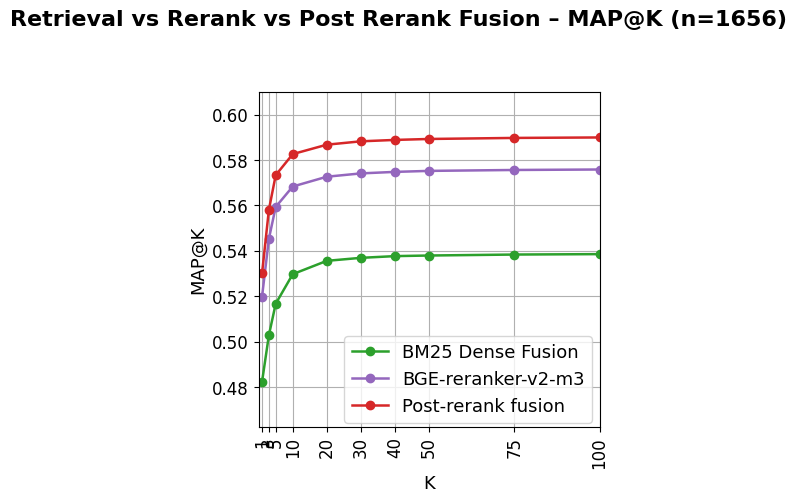

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/04b_hybrid_rerank_fusion_mrrk_per_split.png


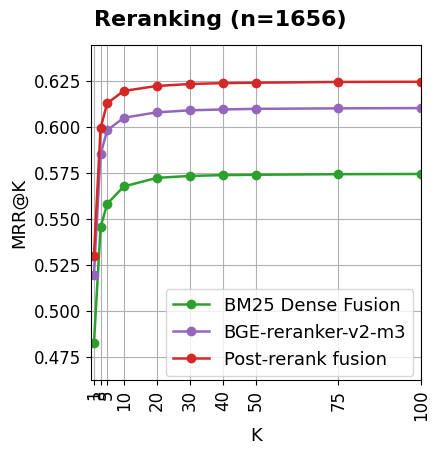

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/04_hybrid_rerank_mapk_per_split_no_post_fusion.png


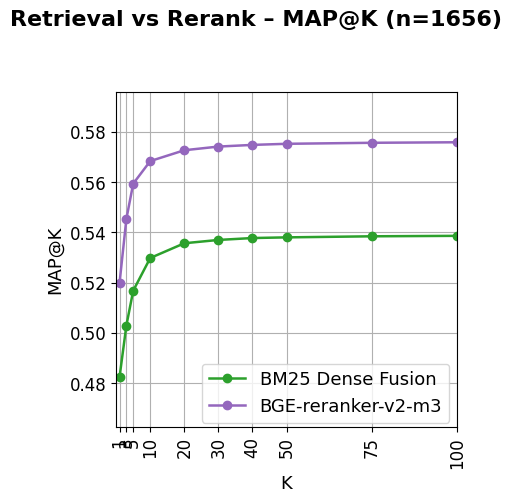

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/04c_hybrid_rerank_mrrk_per_split_no_post_fusion.png


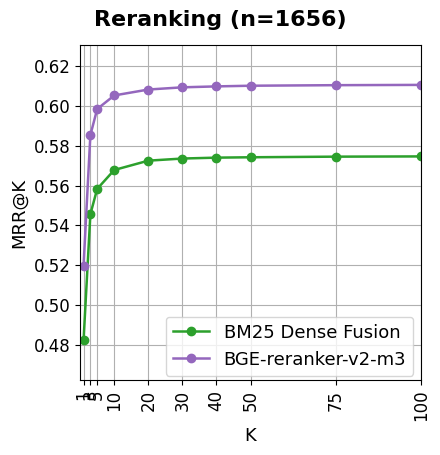

In [145]:
map_ks = [1, 3, 5, 10, 20, 30, 40, 50, 75, 100]


def _load_run(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return df[[qid_col, doc_col]]


def _ap_at_k(docs: list[str], rels: set[str], k: int) -> float:
    if not rels:
        return 0.0
    denom = min(len(rels), k)
    if denom == 0:
        return 0.0
    hits = 0
    score = 0.0
    for i, doc in enumerate(docs[:k], start=1):
        if doc in rels:
            hits += 1
            score += hits / i
    return score / denom


def _mrr_at_k(docs: list[str], rels: set[str], k: int) -> float:
    for i, doc in enumerate(docs[:k], start=1):
        if doc in rels:
            return 1.0 / i
    return 0.0


def _recall_at_k(docs: list[str], rels: set[str], k: int) -> float:
    if not rels:
        return 0.0
    hits = sum(1 for d in docs[:k] if d in rels)
    return hits / len(rels)


def _map_at_ks_for_run(run_df: pd.DataFrame, qrels: dict[str, set[str]], ks: list[int]) -> dict[int, float]:
    qid_col, doc_col = run_df.columns.tolist()
    per_q: dict[int, list[float]] = {k: [] for k in ks}
    for qid, group in run_df.groupby(qid_col, sort=False):
        rels = qrels.get(str(qid))
        if not rels:
            continue
        docs = group[doc_col].tolist()
        for k in ks:
            per_q[k].append(_ap_at_k(docs, rels, k))
    return {k: (float(np.mean(v)) if v else 0.0) for k, v in per_q.items()}


def _mrr_at_ks_for_run(run_df: pd.DataFrame, qrels: dict[str, set[str]], ks: list[int]) -> dict[int, float]:
    qid_col, doc_col = run_df.columns.tolist()
    per_q: dict[int, list[float]] = {k: [] for k in ks}
    for qid, group in run_df.groupby(qid_col, sort=False):
        rels = qrels.get(str(qid))
        if not rels:
            continue
        docs = group[doc_col].tolist()
        for k in ks:
            per_q[k].append(_mrr_at_k(docs, rels, k))
    return {k: (float(np.mean(v)) if v else 0.0) for k, v in per_q.items()}

run_dirs = {
    "BM25 Dense Fusion": retrieval_dir / "fusion" / "runs",
    "BGE-m3": rerank_dir / "cross_encoder" / "runs",
    "Post-rerank fusion": rerank_dir / "post_rerank_fusion_snippet" / "runs",
}

map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)
mrr_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits:
    qrels_split = qrels_by_split.get(split, {})
    for method_name, runs_dir in run_dirs.items():
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)
        map_curves[method_name][split] = _map_at_ks_for_run(run_df, qrels_split, map_ks)
        mrr_curves[method_name][split] = _mrr_at_ks_for_run(run_df, qrels_split, map_ks)

fig, axes = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

all_maps = []
for method_dict in map_curves.values():
    for split_vals in method_dict.values():
        all_maps.extend(split_vals.values())

if all_maps:
    y_min = max(0.0, min(all_maps) - 0.02)
    y_max = min(1.0, max(all_maps) + 0.02)
else:
    y_min, y_max = 0.0, 1.0

# v2-m3: same purple as `04_hybrid_rerank_mapk_per_split_no_post_fusion.png` (colors_map_rr).
# Post-fusion: `#d62728` appears elsewhere in this report (e.g. evidence / S6) but not in `01_stage1_recall_per_split.png`.
colors_map = {
    "BM25 Dense Fusion": "#2ca02c",
    "BGE-m3": "#9467bd",
    "Post-rerank fusion": "#d62728",
}

for idx, split in enumerate(splits):
    ax = axes[idx]
    for method_name, method_dict in map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(
            map_ks,
            vals,
            marker="o",
            color=colors_map.get(method_name),
            label=method_name,
            linewidth=1.8,
        )
    _axis_split_title(ax, split)
    ax.set_ylim(y_min, y_max)

    if idx == 0:
        ax.set_ylabel("MAP@K")
    else:
        ax.set_ylabel("")

    ax.set_xlabel("K")
    ax.set_xticks(map_ks)
    ax.set_xticklabels([str(k) for k in map_ks], rotation=90)
    ax.set_xlim(0, 100)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=13)

fig.suptitle(_suptitle_n("Retrieval vs Rerank vs Post Rerank Fusion – MAP@K"), fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path = output_dir / "04_hybrid_rerank_fusion_mapk_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

# --- MRR@K version (mirrors MAP@K figure above) ---
all_mrrs = [v for md in mrr_curves.values() for sv in md.values() for v in sv.values()]
if all_mrrs:
    y_min_mrr = max(0.0, min(all_mrrs) - 0.02)
    y_max_mrr = min(1.0, max(all_mrrs) + 0.02)
else:
    y_min_mrr, y_max_mrr = 0.0, 1.0

fig_mrr, axes_mrr = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes_mrr = axes_mrr.ravel()
for idx, split in enumerate(splits):
    ax = axes_mrr[idx]
    for method_name, method_dict in mrr_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(map_ks, vals, marker="o", color=colors_map.get(method_name), label=method_name, linewidth=1.8)
    _axis_split_title(ax, split)
    ax.set_ylim(y_min_mrr, y_max_mrr)
    ax.set_ylabel("MRR@K" if idx == 0 else "")
    ax.set_xlabel("K")
    ax.set_xticks(map_ks)
    ax.set_xticklabels([str(k) for k in map_ks], rotation=90)
    ax.set_xlim(0, 100)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
handles_mrr, labels_mrr = axes_mrr[0].get_legend_handles_labels()
fig_mrr.legend(handles_mrr, labels_mrr, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=13)
fig_mrr.suptitle(_suptitle_n("Reranking"), fontsize=16, fontweight="bold", y=0.9)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path_mrr = output_dir / "04b_hybrid_rerank_fusion_mrrk_per_split.png"
plt.savefig(fig_path_mrr, dpi=150, bbox_inches="tight")
print("Saved:", fig_path_mrr)
plt.show()

# Same MAP@K curves without post-rerank fusion (clearer when fusion overlaps / dominates).
map_curves_rr = {k: v for k, v in map_curves.items() if k != "Post-rerank fusion"}
mrr_curves_rr = {k: v for k, v in mrr_curves.items() if k != "Post-rerank fusion"}
colors_map_rr = {
    "BM25 Dense Fusion": colors_map["BM25 Dense Fusion"],
    "BGE-m3": "#9467bd",
}
all_maps_rr = []
for method_dict in map_curves_rr.values():
    for split_vals in method_dict.values():
        all_maps_rr.extend(split_vals.values())

if all_maps_rr:
    y_min_rr = max(0.0, min(all_maps_rr) - 0.02)
    y_max_rr = min(1.0, max(all_maps_rr) + 0.02)
else:
    y_min_rr, y_max_rr = 0.0, 1.0

fig2, axes2 = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes2 = axes2.ravel()
for idx, split in enumerate(splits):
    ax = axes2[idx]
    for method_name, method_dict in map_curves_rr.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(map_ks, vals, marker="o", color=colors_map_rr.get(method_name), label=method_name, linewidth=1.8)
    _axis_split_title(ax, split)
    ax.set_ylim(y_min_rr, y_max_rr)
    ax.set_ylabel("MAP@K" if idx == 0 else "")
    ax.set_xlabel("K")
    ax.set_xticks(map_ks)
    ax.set_xticklabels([str(k) for k in map_ks], rotation=90)
    ax.set_xlim(0, 100)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

handles2, labels2 = axes2[0].get_legend_handles_labels()
fig2.legend(handles2, labels2, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=13)
fig2.suptitle(_suptitle_n("Retrieval vs Rerank – MAP@K"), fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path_rr = output_dir / "04_hybrid_rerank_mapk_per_split_no_post_fusion.png"
plt.savefig(fig_path_rr, dpi=150, bbox_inches="tight")
print("Saved:", fig_path_rr)
plt.show()

# --- MRR@K no-fusion version ---
all_mrrs_rr = [v for md in mrr_curves_rr.values() for sv in md.values() for v in sv.values()]
if all_mrrs_rr:
    y_min_mrr_rr = max(0.0, min(all_mrrs_rr) - 0.02)
    y_max_mrr_rr = min(1.0, max(all_mrrs_rr) + 0.02)
else:
    y_min_mrr_rr, y_max_mrr_rr = 0.0, 1.0

fig2_mrr, axes2_mrr = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(4.5 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes2_mrr = axes2_mrr.ravel()
for idx, split in enumerate(splits):
    ax = axes2_mrr[idx]
    for method_name, method_dict in mrr_curves_rr.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(map_ks, vals, marker="o", color=colors_map_rr.get(method_name), label=method_name, linewidth=1.8)
    _axis_split_title(ax, split)
    ax.set_ylim(y_min_mrr_rr, y_max_mrr_rr)
    ax.set_ylabel("MRR@K" if idx == 0 else "")
    ax.set_xlabel("K")
    ax.set_xticks(map_ks)
    ax.set_xticklabels([str(k) for k in map_ks], rotation=90)
    ax.set_xlim(0, 100)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
handles2_mrr, labels2_mrr = axes2_mrr[0].get_legend_handles_labels()
fig2_mrr.legend(handles2_mrr, labels2_mrr, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=13)
fig2_mrr.suptitle(_suptitle_n("Reranking"), fontsize=16, fontweight="bold", y=0.9)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path_mrr_rr = output_dir / "04c_hybrid_rerank_mrrk_per_split_no_post_fusion.png"
plt.savefig(fig_path_mrr_rr, dpi=150, bbox_inches="tight")
print("Saved:", fig_path_mrr_rr)
plt.show()

## Fig S1 (paper): Stage-1 recall + rerank MRR@K (1×2)
Same data as `01_stage1_recall_per_split.png` and `04b_hybrid_rerank_fusion_mrrk_per_split.png`, redrawn side-by-side for the paper. Left panel uses **linear** K from **x = 0** (unlike the standalone stage-1 PNG, which uses log-scaled K). Right panel matches the fusion MRR@K figure (three methods, same K and colors).

Saved: /Users/yun/develop/dictycite/output/paper_figures/fig_s1.png


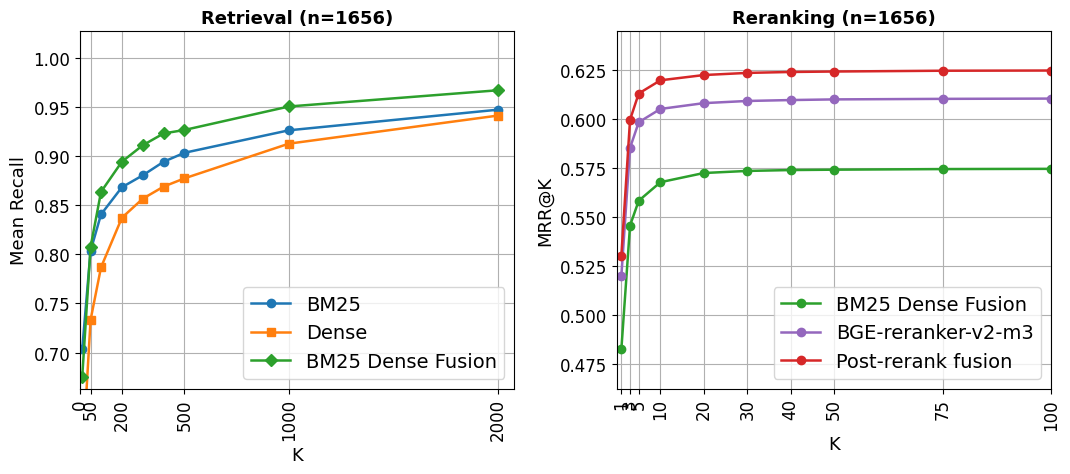

In [146]:
fig_s1, axes_s1 = plt.subplots(1, 2, figsize=(10.8, 4.85), squeeze=False)
axes_s1 = axes_s1.ravel()

# Left: stage-1 mean recall@K (linear x)
ax_l = axes_s1[0]
_s1_recall_max = 0.0
for split in splits:
    for method_name, cfg in methods_cfg.items():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols]
        _s1_recall_max = max(_s1_recall_max, max(vals))
        ax_l.plot(
            k_values,
            vals,
            marker=cfg["marker"],
            color=cfg["color"],
            label=method_name,
            markersize=6,
            linewidth=1.8,
        )
    _axis_split_title(ax_l, split)

_s1_y_top = min(1.12, _s1_recall_max + 0.06)
ax_l.set_ylim(global_ymin, max(_s1_y_top, global_ymin + 0.02))
ax_l.set_ylabel("Mean Recall")
ax_l.set_xlabel("K")
_k_hi = max(k_values)
_k_lo = min(k_values)
ax_l.set_xlim(0, _k_hi + 0.04 * (_k_hi - _k_lo))
_ticks_s1 = sorted({0, *tick_values})
ax_l.set_xticks(_ticks_s1)
ax_l.set_xticklabels([str(t) for t in _ticks_s1], rotation=90)
ax_l.grid(True, axis="y")
ax_l.grid(True, axis="x")
ax_l.set_title(_suptitle_n("Retrieval"), fontsize=13, fontweight="bold", pad=6)
ax_l.legend(loc="lower right", fontsize=14)

# Right: same MRR@K curves as `04b_hybrid_rerank_fusion_mrrk_per_split.png` (incl. post-rerank fusion).
ax_r = axes_s1[1]
for idx, split in enumerate(splits):
    for method_name, method_dict in mrr_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax_r.plot(
            map_ks,
            vals,
            marker="o",
            color=colors_map.get(method_name),
            label=method_name,
            linewidth=1.8,
        )
    _axis_split_title(ax_r, split)
    ax_r.set_ylim(y_min_mrr, y_max_mrr)
    ax_r.set_ylabel("MRR@K" if idx == 0 else "")
    ax_r.set_xlabel("K")
    ax_r.set_xticks(map_ks)
    ax_r.set_xticklabels([str(k) for k in map_ks], rotation=90)
    ax_r.set_xlim(0, 100)
    ax_r.grid(True, axis="y")
    ax_r.grid(True, axis="x")
ax_r.set_title(_suptitle_n("Reranking"), fontsize=13, fontweight="bold", pad=6)
ax_r.legend(loc="lower right", fontsize=14)

plt.tight_layout(w_pad=1.6)
fig_s1_out = paper_figures_dir / "fig_s1_baseline_depths.png"
plt.savefig(fig_s1_out, dpi=150, bbox_inches="tight")
print("Saved:", fig_s1_out)
plt.show()

## 8. Gold Count Histogram per Query (7a full public)

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/05_gold_count_hist_all.png


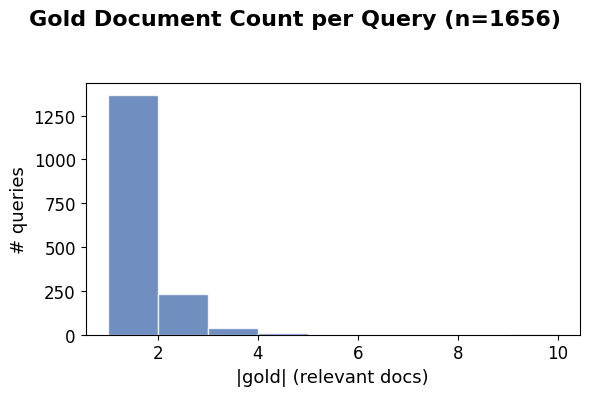

In [129]:
gold_split = splits[0]

gold_counts_all = [len(v) for v in qrels_by_split[gold_split].values()]

max_gold = max(gold_counts_all) if gold_counts_all else 0
bins = range(1, max_gold + 2) if max_gold > 0 else [0, 1]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gold_counts_all, bins=bins, color="#4c72b0", alpha=0.8, edgecolor="white")
ax.set_xlabel("|gold| (relevant docs)")
ax.set_ylabel("# queries")

fig.suptitle(_suptitle_n("Gold Document Count per Query"), fontsize=16, fontweight="bold", y=0.98)
_hist_rect = [0, 0, 1, 0.92] if _N_SPLIT_COLS <= 1 else [0, 0, 1, 1.0]
plt.tight_layout(rect=_hist_rect)
fig_path = output_dir / "05_gold_count_hist_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 9. MAP@K Stratified by Gold Count (7a; |gold| = 1, >1)

Per-query AP@K rows: 49680
Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/06_mapk_by_gold_bucket_all.png


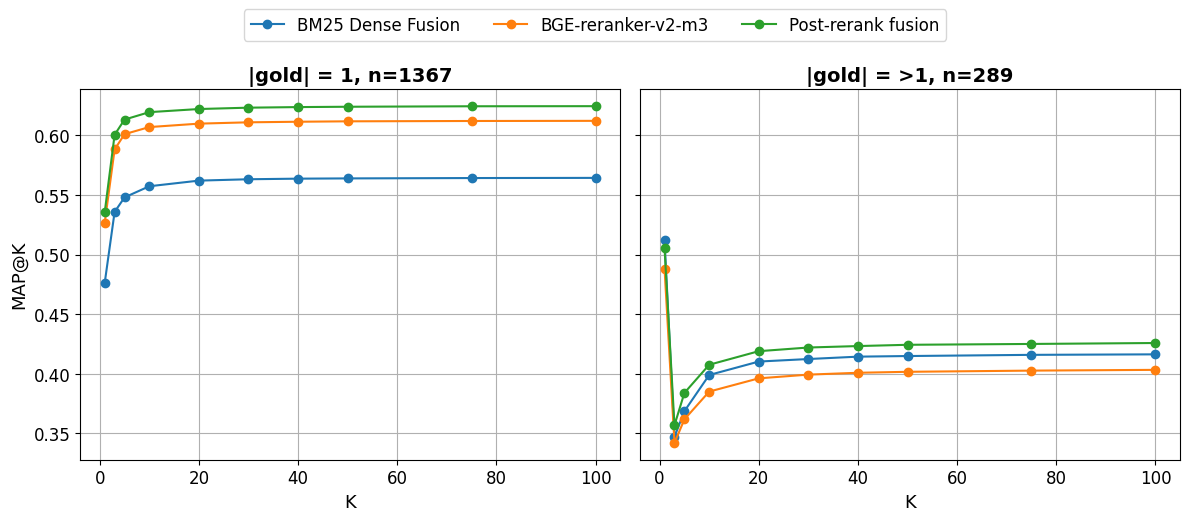

In [130]:
bucket_order = ["1", ">1"]


def _gold_bucket(n: int) -> str:
    if n == 1:
        return "1"
    return ">1"


records = []
for method_name, runs_dir in run_dirs.items():
    for split in splits:
        qrels_split = qrels_by_split[split]
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)

        qid_col, doc_col = run_df.columns.tolist()
        for qid, group in run_df.groupby(qid_col, sort=False):
            rels = qrels_split.get(str(qid))
            if not rels:
                continue
            gold_n = len(rels)
            bucket = _gold_bucket(gold_n)
            docs = group[doc_col].tolist()
            for k in map_ks:
                ap = _ap_at_k(docs, set(rels), k)
                records.append(
                    {
                        "split": split,
                        "method": method_name,
                        "qid": str(qid),
                        "gold_n": gold_n,
                        "bucket": bucket,
                        "k": k,
                        "AP@K": ap,
                    }
                )

map_pq_df = pd.DataFrame(records)
print("Per-query AP@K rows:", len(map_pq_df))

summary = (
    map_pq_df.groupby(["method", "bucket", "k"], as_index=False)["AP@K"]
    .mean()
    .rename(columns={"AP@K": "MAP@K"})
)

bucket_counts = (
    map_pq_df[["qid", "bucket"]]
    .drop_duplicates()
    .groupby("bucket")["qid"]
    .nunique()
    .to_dict()
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

for idx, bucket in enumerate(bucket_order):
    ax = axes[idx]
    bucket_df = summary[summary["bucket"] == bucket]
    if bucket_df.empty:
        ax.set_visible(False)
        continue
    for method_name in run_dirs.keys():
        m_df = bucket_df[bucket_df["method"] == method_name]
        if m_df.empty:
            continue
        ax.plot(
            m_df["k"],
            m_df["MAP@K"],
            marker="o",
            label=method_name,
        )
    n_bucket = bucket_counts.get(bucket, 0)
    ax.set_title(f"|gold| = {bucket}, n={n_bucket}", fontweight="bold")
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx == 0:
        ax.set_ylabel("MAP@K")
    ax.set_xlabel("K")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(run_dirs), bbox_to_anchor=(0.5, 1.05), fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "06_mapk_by_gold_bucket_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/06b_mapk_recall_by_gold_bucket_all.png


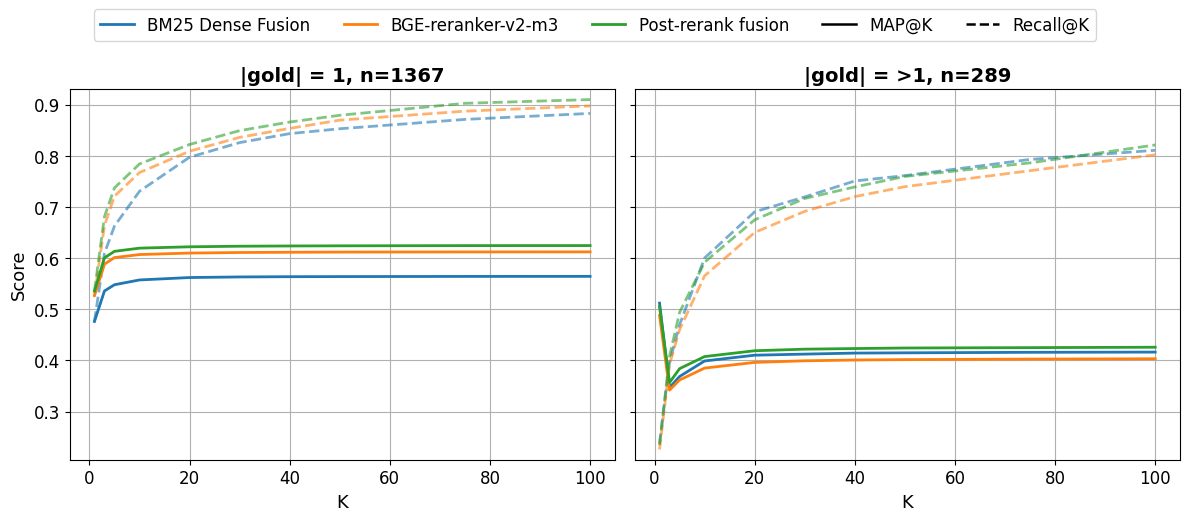

In [131]:
recall_records = []
for method_name, runs_dir in run_dirs.items():
    for split in splits:
        qrels_split = qrels_by_split[split]
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)
        qid_col, doc_col = run_df.columns.tolist()
        for qid, group in run_df.groupby(qid_col, sort=False):
            rels = qrels_split.get(str(qid))
            if not rels:
                continue
            docs = group[doc_col].tolist()
            bucket = _gold_bucket(len(rels))
            for k in map_ks:
                recall_records.append({
                    "method": method_name,
                    "bucket": bucket,
                    "k": k,
                    "Recall@K": _recall_at_k(docs, set(rels), k),
                })

recall_pq_df = pd.DataFrame(recall_records)
recall_summary = (
    recall_pq_df.groupby(["method", "bucket", "k"], as_index=False)["Recall@K"]
    .mean()
)

combined = summary.merge(recall_summary, on=["method", "bucket", "k"], how="outer")

all_vals = list(combined["MAP@K"].dropna()) + list(combined["Recall@K"].dropna())
y_min_c = max(0.0, min(all_vals) - 0.02) if all_vals else 0.0
y_max_c = min(1.0, max(all_vals) + 0.02) if all_vals else 1.0

method_colors_combined = {name: f"C{i}" for i, name in enumerate(run_dirs)}

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

for idx, bucket in enumerate(bucket_order):
    ax = axes[idx]
    bucket_df = combined[combined["bucket"] == bucket]
    if bucket_df.empty:
        ax.set_visible(False)
        continue
    for method_name in run_dirs:
        m_df = bucket_df[bucket_df["method"] == method_name].sort_values("k")
        if m_df.empty:
            continue
        c = method_colors_combined[method_name]
        ax.plot(
            m_df["k"],
            m_df["MAP@K"],
            color=c,
            linewidth=2.0,
        )
        ax.plot(
            m_df["k"],
            m_df["Recall@K"],
            color=c,
            linewidth=2.0,
            linestyle="--",
            alpha=0.6,
        )
    n_bucket = bucket_counts.get(bucket, 0)
    ax.set_title(f"|gold| = {bucket}, n={n_bucket}", fontweight="bold")
    ax.set_ylim(y_min_c, y_max_c)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx == 0:
        ax.set_ylabel("Score")
    ax.set_xlabel("K")

method_handles = [
    Line2D([], [], color=method_colors_combined[m], linewidth=2.0, label=m)
    for m in run_dirs
]
style_handles = [
    Line2D([], [], color="black", linewidth=1.8, linestyle="-", label="MAP@K"),
    Line2D([], [], color="black", linewidth=1.8, linestyle="--", label="Recall@K"),
]
fig.legend(
    handles=method_handles + style_handles,
    loc="upper center",
    ncol=len(run_dirs) + 2,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=12,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "06b_mapk_recall_by_gold_bucket_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 11. Snippet Rerank vs Rerank Hybrid 200 – MAP@K Curves

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/08_snippet_rerank_vs_rerank_hybrid200_mapk.png


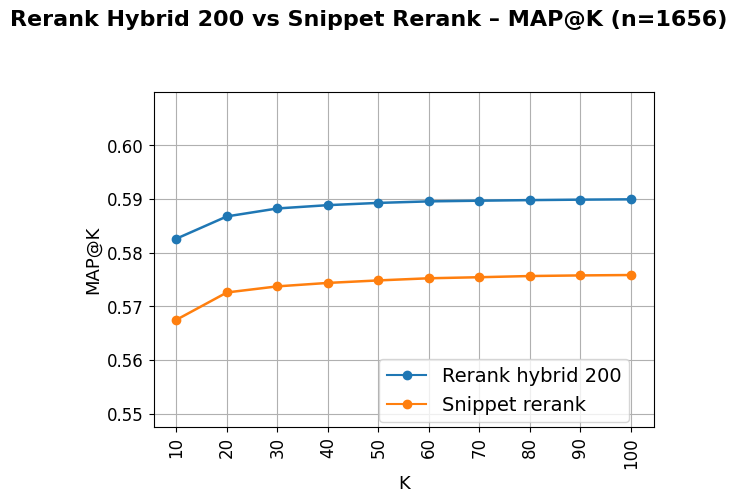

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/08b_snippet_rerank_vs_rerank_hybrid200_mrrk.png


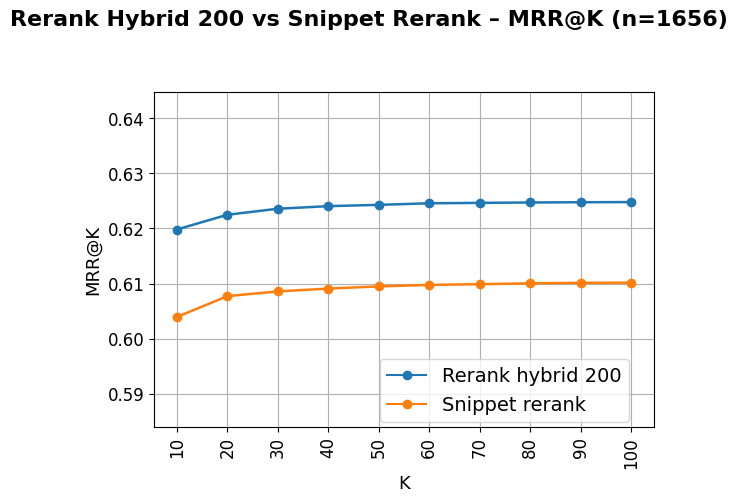

In [132]:
snippet_run_dirs = {
    "Rerank hybrid 200": rerank_dir / "post_rerank_fusion_snippet" / "runs",
    "Snippet rerank": snippet_dir / "snippet_rerank" / "runs",
}

snippet_map_ks = list(range(10, 101, 10))

snippet_map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)
snippet_mrr_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue
    for method_name, runs_dir in snippet_run_dirs.items():
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)
        snippet_map_curves[method_name][split] = _map_at_ks_for_run(run_df, qrels_split, snippet_map_ks)
        snippet_mrr_curves[method_name][split] = _mrr_at_ks_for_run(run_df, qrels_split, snippet_map_ks)

fig, axes = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(6 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes = axes.ravel()

all_vals_snippet: list[float] = []
for method_dict in snippet_map_curves.values():
    for split_vals in method_dict.values():
        all_vals_snippet.extend(split_vals.values())

if all_vals_snippet:
    y_min_s = max(0.0, min(all_vals_snippet) - 0.02)
    y_max_s = min(1.0, max(all_vals_snippet) + 0.02)
else:
    y_min_s, y_max_s = 0.0, 1.0

colors_snippet = {
    "Rerank hybrid 200": "#1f77b4",
    "Snippet rerank": "#ff7f0e",
}

for idx, split in enumerate(splits):
    ax = axes[idx]
    for method_name, method_dict in snippet_map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in snippet_map_ks]
        ax.plot(
            snippet_map_ks,
            vals,
            marker="o",
            linewidth=1.8,
            color=colors_snippet[method_name],
            label=method_name,
        )
    _axis_split_title(ax, split, fontsize=14)
    ax.set_ylim(y_min_s, y_max_s)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx == 0:
        ax.set_ylabel("MAP@K")
    ax.set_xlabel("K")
    ax.set_xticks(snippet_map_ks)
    ax.set_xticklabels([str(k) for k in snippet_map_ks], rotation=90)

legend_snippet_handles = [
    Line2D([0], [0], color=colors_snippet[name], marker="o", linestyle="-", label=name)
    for name in colors_snippet
]
fig.legend(
    handles=legend_snippet_handles,
    labels=list(colors_snippet),
    loc="lower right",
    bbox_to_anchor=(0.95, 0.15),
    fontsize=14,
)
fig.suptitle(
    _suptitle_n("Rerank Hybrid 200 vs Snippet Rerank – MAP@K"),
    fontsize=16,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path = output_dir / "08_snippet_rerank_vs_rerank_hybrid200_mapk.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

# --- MRR@K version ---
all_vals_snippet_mrr = [v for md in snippet_mrr_curves.values() for sv in md.values() for v in sv.values()]
if all_vals_snippet_mrr:
    y_min_s_mrr = max(0.0, min(all_vals_snippet_mrr) - 0.02)
    y_max_s_mrr = min(1.0, max(all_vals_snippet_mrr) + 0.02)
else:
    y_min_s_mrr, y_max_s_mrr = 0.0, 1.0

fig_s_mrr, axes_s_mrr = plt.subplots(
    1, _N_SPLIT_COLS, figsize=(6 * _N_SPLIT_COLS, 5), sharex=True, sharey=True, squeeze=False
)
axes_s_mrr = axes_s_mrr.ravel()
for idx, split in enumerate(splits):
    ax = axes_s_mrr[idx]
    for method_name, method_dict in snippet_mrr_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in snippet_map_ks]
        ax.plot(snippet_map_ks, vals, marker="o", linewidth=1.8, color=colors_snippet[method_name], label=method_name)
    _axis_split_title(ax, split, fontsize=14)
    ax.set_ylim(y_min_s_mrr, y_max_s_mrr)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    ax.set_ylabel("MRR@K" if idx == 0 else "")
    ax.set_xlabel("K")
    ax.set_xticks(snippet_map_ks)
    ax.set_xticklabels([str(k) for k in snippet_map_ks], rotation=90)
legend_s_mrr = [Line2D([0], [0], color=colors_snippet[n], marker="o", label=n) for n in colors_snippet]
fig_s_mrr.legend(handles=legend_s_mrr, loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=14)
fig_s_mrr.suptitle(_suptitle_n("Rerank Hybrid 200 vs Snippet Rerank – MRR@K"), fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout(rect=_TIGHT_RECT)
fig_path_s_mrr = output_dir / "08b_snippet_rerank_vs_rerank_hybrid200_mrrk.png"
plt.savefig(fig_path_s_mrr, dpi=150, bbox_inches="tight")
print("Saved:", fig_path_s_mrr)
plt.show()

## 12. RRF Fusion Sweep: MAP@10 vs Weight (rerank_hybrid_200 + snippet_rerank)

Saved: /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/09_rrf_fusion_map10_vs_weight.png


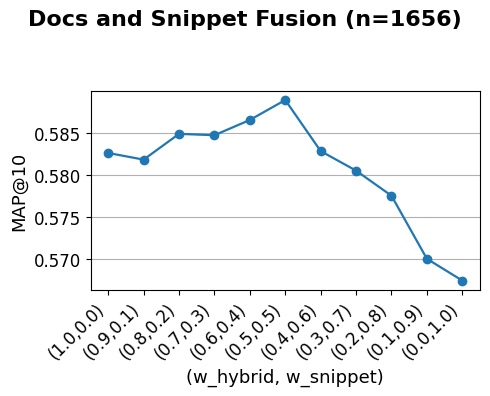

In [133]:
RUN_TOP = 100
OUTPUT_TOP = 10
RRF_KS = [60]
RRF_WEIGHTS = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),
    (0.0, 1.0),
]


def _build_run_map(run_df: pd.DataFrame) -> dict[str, list[str]]:
    qid_col, doc_col = run_df.columns.tolist()
    run_map: dict[str, list[str]] = {}
    for qid, group in run_df.groupby(qid_col, sort=False):
        run_map[str(qid)] = group[doc_col].astype(str).tolist()
    return run_map


def _rrf_fuse_docs(
    docs_hybrid: list[str],
    docs_snippet: list[str],
    k_rrf: int,
    w_hybrid: float,
    w_snippet: float,
    run_top: int,
    output_top: int,
) -> list[str]:
    hybrid_top = docs_hybrid[:run_top]
    snippet_top = docs_snippet[:run_top]
    rank_h = {d: i + 1 for i, d in enumerate(hybrid_top)}
    rank_s = {d: i + 1 for i, d in enumerate(snippet_top)}
    union = list(dict.fromkeys(hybrid_top + snippet_top))
    scored: list[tuple[str, float]] = []
    for d in union:
        s = 0.0
        rh = rank_h.get(d)
        rs = rank_s.get(d)
        if rh is not None:
            s += w_hybrid / (k_rrf + rh)
        if rs is not None:
            s += w_snippet / (k_rrf + rs)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored[:output_top]]


def _ap10_for_fusion(
    gold: dict[str, set[str]],
    run_hybrid: dict[str, list[str]],
    run_snippet: dict[str, list[str]],
    k_rrf: int,
    w_hybrid: float,
    w_snippet: float,
) -> tuple[float, int]:
    qids = [q for q in gold if q in run_hybrid and q in run_snippet and gold[q]]
    if not qids:
        return 0.0, 0
    ap_vals: list[float] = []
    for q in qids:
        rels = set(gold[q])
        fused_docs = _rrf_fuse_docs(
            run_hybrid[q],
            run_snippet[q],
            k_rrf=k_rrf,
            w_hybrid=w_hybrid,
            w_snippet=w_snippet,
            run_top=RUN_TOP,
            output_top=OUTPUT_TOP,
        )
        ap_vals.append(_ap_at_k(fused_docs, rels, k=OUTPUT_TOP))
    return (float(np.mean(ap_vals)) if ap_vals else 0.0, len(qids))


hybrid_run_maps: dict[str, dict[str, list[str]]] = {}
snippet_run_maps_sweep: dict[str, dict[str, list[str]]] = {}

for split in splits:
    h_dir = rerank_dir / "post_rerank_fusion_snippet" / "runs"
    h_candidates = list(h_dir.glob(f"best_rrf_{split}_top5000*.tsv"))
    s_dir = snippet_dir / "snippet_rerank" / "runs"
    s_candidates = list(s_dir.glob(f"best_rrf_{split}_top5000*.tsv"))

    if not h_candidates or not s_candidates:
        continue

    df_h = _load_run(h_candidates[0])
    df_s = _load_run(s_candidates[0])

    hybrid_run_maps[split] = _build_run_map(df_h)
    snippet_run_maps_sweep[split] = _build_run_map(df_s)

rrf_rows: list[dict[str, object]] = []

for split in splits:
    gold = qrels_by_split.get(split)
    run_h = hybrid_run_maps.get(split)
    run_s = snippet_run_maps_sweep.get(split)
    if not gold or not run_h or not run_s:
        continue
    for k_rrf in RRF_KS:
        for w_h, w_s in RRF_WEIGHTS:
            map10, n_q = _ap10_for_fusion(
                gold=gold,
                run_hybrid=run_h,
                run_snippet=run_s,
                k_rrf=k_rrf,
                w_hybrid=w_h,
                w_snippet=w_s,
            )
            rrf_rows.append(
                {
                    "split": split,
                    "k_rrf": k_rrf,
                    "w_hybrid": w_h,
                    "w_snippet": w_s,
                    "MAP@10": map10,
                    "n_queries": n_q,
                }
            )

rrf_results = pd.DataFrame(rrf_rows)
if not rrf_results.empty:
    rrf_results["weight_label"] = rrf_results.apply(
        lambda r: f"({r['w_hybrid']:.1f},{r['w_snippet']:.1f})",
        axis=1,
    )

weight_order = [f"({w[0]:.1f},{w[1]:.1f})" for w in RRF_WEIGHTS]

if not rrf_results.empty:
    n_splits = rrf_results["split"].nunique()
    fig, axes = plt.subplots(1, n_splits, figsize=(5 * n_splits, 4), sharey=True)
    if n_splits == 1:
        axes = np.array([axes])
    axes_flat = list(axes.flat)

    for idx, (ax, (split, grp)) in enumerate(zip(axes_flat, rrf_results.groupby("split", sort=False))):
        for k_rrf in sorted(grp["k_rrf"].unique()):
            sub = grp[grp["k_rrf"] == k_rrf].set_index("weight_label").reindex(weight_order)
            vals = sub["MAP@10"].values
            ax.plot(
                range(len(weight_order)),
                vals,
                marker="o",
                linewidth=1.6,
            )
        ax.set_xticks(range(len(weight_order)))
        ax.set_xticklabels(weight_order, rotation=45, ha="right")
        n_q = int(grp["n_queries"].max())
        if _N_SPLIT_COLS > 1:
            ax.set_title(f"{split_labels.get(split, split)} (n={n_q})", fontsize=12, fontweight="bold")
        if idx == 0:
            ax.set_ylabel("MAP@10")
        ax.set_xlabel("(w_hybrid, w_snippet)")
        ax.grid(True, axis="y")

    if _N_SPLIT_COLS <= 1:
        n_q_title = int(rrf_results["n_queries"].max())
        fig.suptitle(f"Docs and Snippet Fusion (n={n_q_title})", fontsize=16, fontweight="bold", y=0.98)
        _rrf_rect = [0, 0, 1, 0.90]
    else:
        fig.suptitle("Docs and Snippet Fusion", fontsize=16, fontweight="bold", y=0.95)
        _rrf_rect = [0, 0, 1, 0.95]
    plt.tight_layout(rect=_rrf_rect)
fig_path = output_dir / "09_rrf_fusion_map10_vs_weight.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 13. Evidence-level setup — qrels + has-PDF subset (source for Fig 5 / Fig S3)

Loads per-evidence-level qrels from the goldset JSONL and the has-PDF subset
filter from `output/dicty_gold_build/7a_dicty_gold_pdf_coverage.tsv`. Both
are consumed by §13 (Fig 5 / Fig S3).

In [134]:
import csv

EVIDENCE_LEVEL_ORDER = [
    "abstract_supports_detail",
    "abstract_supports_core",
    "abstract_insufficient",
]
EVIDENCE_FIG3_COLORS = {
    "abstract_supports_detail":   "#1f77b4",
    "abstract_supports_core":     "#2ca02c",
    "abstract_insufficient":      "#d62728",
}
EVIDENCE_FIG3_LABELS = {
    "abstract_supports_detail":   "Abstract supports detail",
    "abstract_supports_core":     "Abstract supports core",
    "abstract_insufficient":      "Abstract insufficient",
}


def _load_qrels_by_evidence_level(gold_jsonl: Path) -> dict[str, dict[str, set[str]]]:
    """Return {evidence_level: {qid: {pmid, ...}}} where each pmid belongs only to
    the level assigned to it in the docs list. A single qid can appear in multiple
    levels if its gold docs carry different evidence labels."""
    level_qrels: dict[str, dict[str, set[str]]] = {}
    with gold_jsonl.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            for doc in (q.get("docs") or []):
                level = (doc.get("evidence_level") or "unknown").strip() or "unknown"
                pmid = str(doc.get("pmid") or "")
                if pmid:
                    level_qrels.setdefault(level, {}).setdefault(qid, set()).add(pmid)
    return level_qrels


# Per-evidence-level qrels for the primary split.
split = splits[0]
level_qrels = _load_qrels_by_evidence_level(qrels_paths[split])
levels_present = sorted(level_qrels.keys())
levels = [lvl for lvl in EVIDENCE_LEVEL_ORDER if lvl in levels_present]
levels += [lvl for lvl in levels_present if lvl not in levels]
print(f"Evidence levels (split={split}):")
for lvl in levels:
    print(f"  {EVIDENCE_FIG3_LABELS.get(lvl, lvl):26s} n_queries={len(level_qrels.get(lvl, {}))}")

# Has-PDF subset filter (claims whose gold PMID is in the v2 chunked corpus).
coverage_tsv = base_dir / "output" / "dicty_gold_build" / "7a_dicty_gold_pdf_coverage.tsv"
chunked_pmids_v2: set[str] = set()
with coverage_tsv.open("r", encoding="utf-8") as f:
    for row in csv.DictReader(f, delimiter="\t"):
        if row.get("in_chunks_v2") == "yes":
            chunked_pmids_v2.add(str(row["pmid"]))
print(f"\nHas-PDF subset: {len(chunked_pmids_v2)} unique chunked PMIDs from coverage TSV")

level_qrels_haspdf: dict[str, dict[str, set[str]]] = {}
for _lvl, q_to_pmids in level_qrels.items():
    new_q = {qid: (pmids & chunked_pmids_v2) for qid, pmids in q_to_pmids.items()}
    new_q = {qid: p for qid, p in new_q.items() if p}
    if new_q:
        level_qrels_haspdf[_lvl] = new_q
print("Has-PDF level_qrels:")
for lvl in levels:
    print(f"  {EVIDENCE_FIG3_LABELS.get(lvl, lvl):26s} n_queries={len(level_qrels_haspdf.get(lvl, {}))}")

Evidence levels (split=7a_dicty_gold_llm_public):
  Abstract supports detail   n_queries=816
  Abstract supports core     n_queries=654
  Abstract insufficient      n_queries=387

Has-PDF subset: 1124 unique chunked PMIDs from coverage TSV
Has-PDF level_qrels:
  Abstract supports detail   n_queries=707
  Abstract supports core     n_queries=585
  Abstract insufficient      n_queries=350


## 14. Fig 5 / Fig S3 — Evidence-level overlay: abstract-only vs +chunked_v2

*Paper role:* main-paper Fig 5 (has-PDF subset) and supplementary Fig S3
(all claims). Two-row 2×3 layout per evidence level:

- **Upper row — first-stage retrieval Recall@K** (BM25+Dense hybrid fusion run,
  `retrieval/fusion`). Shows how often the gold paper is anywhere in the
  retrieved candidate set up to K.
- **Lower row — post-rerank-fusion MRR@K** (cross-encoder + post-rerank
  fusion). Shows how high the gold paper is ranked after reranking.

Together this exposes the "retrieval finds it / rerank can't surface it"
bottleneck on `abstract_insufficient` claims when chunked full-text is added.

Chunked-v2 run docids are chunk-level (`{pmid}#abstract`, `{pmid}#body_NNN`);
we aggregate to PMID by max-pool (first occurrence per query wins). qid sets
are intersected across the two systems so the per-bucket n matches for both
overlays.

When MedCPT post-fusion runs exist under `workflow_vega_7a_public_goldset_rerank_medcpt`
and `workflow_frida_7a_public_goldset_chunked_v2_rerank_medcpt`, **lower-row-only**
figures reuse the same first-stage retrieval as Fig 5 / S5; only MedCPT post-fusion MRR@K
is plotted. They are saved under each workflow's `figures/` (has-PDF → Vega MedCPT dir;
all claims → Frida chunked MedCPT dir), not under `paper_figures/`.

Likewise **BGE-Gemma** lower-row-only figures when post-fusion TSVs exist under
`workflow_frida_7a_public_goldset_rerank_gemma` (abstract) and
`workflow_frida_7a_public_goldset_chunked_v2_rerank_gemma` (chunked v2): has-PDF → abstract
workflow `figures/`, all claims → chunked workflow `figures/`.

Paired per-query metrics CSV: /Users/yun/develop/dictycite/output/workflow_frida_7a_public_goldset_chunked_v2/rerank/post_rerank_fusion/per_query/7a_dicty_gold_llm_public_rrf_poolR300_poolH300_k60.csv
Loaded runs (qids): retrieval base=1656  chunked=1656;  rerank base=1656  chunked=1656
Saved: /Users/yun/develop/dictycite/output/paper_figures/fig5_evidence_level_retrieval_recall_rerank_mrr_haspdf.png


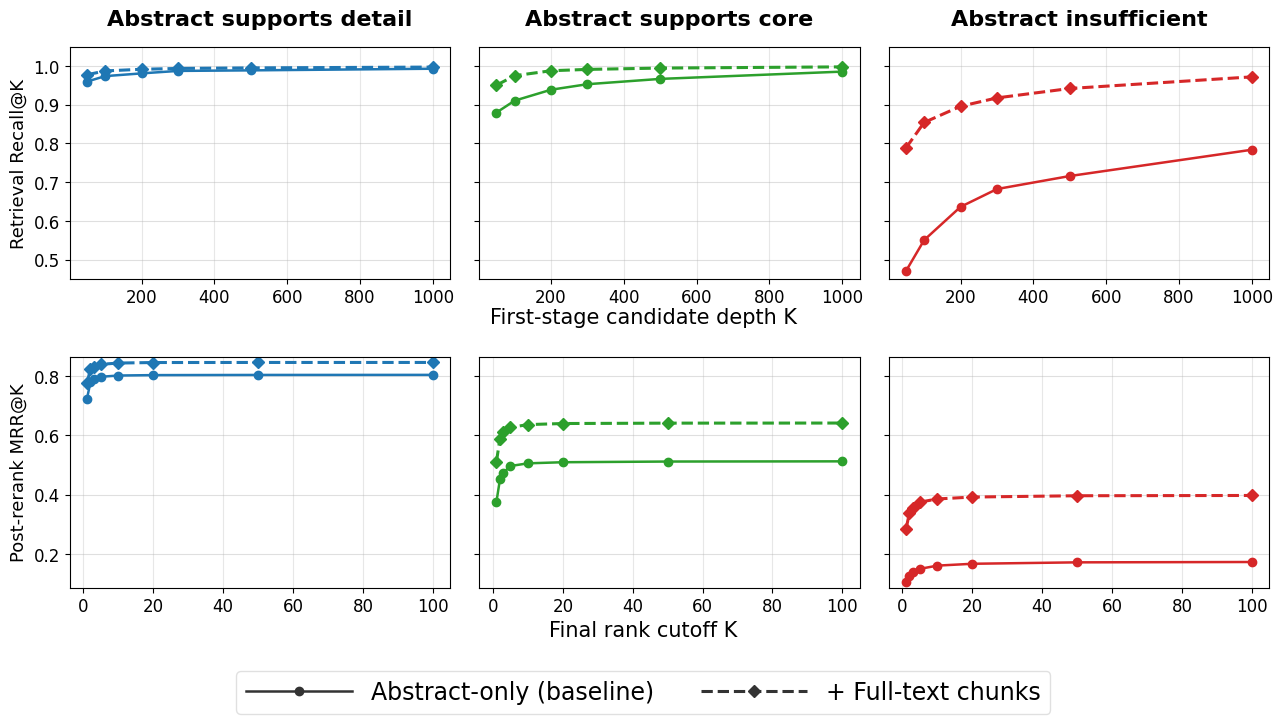

Saved: /Users/yun/develop/dictycite/output/paper_figures/fig_s5_evidence_level_retrieval_recall_rerank_mrr_all.png


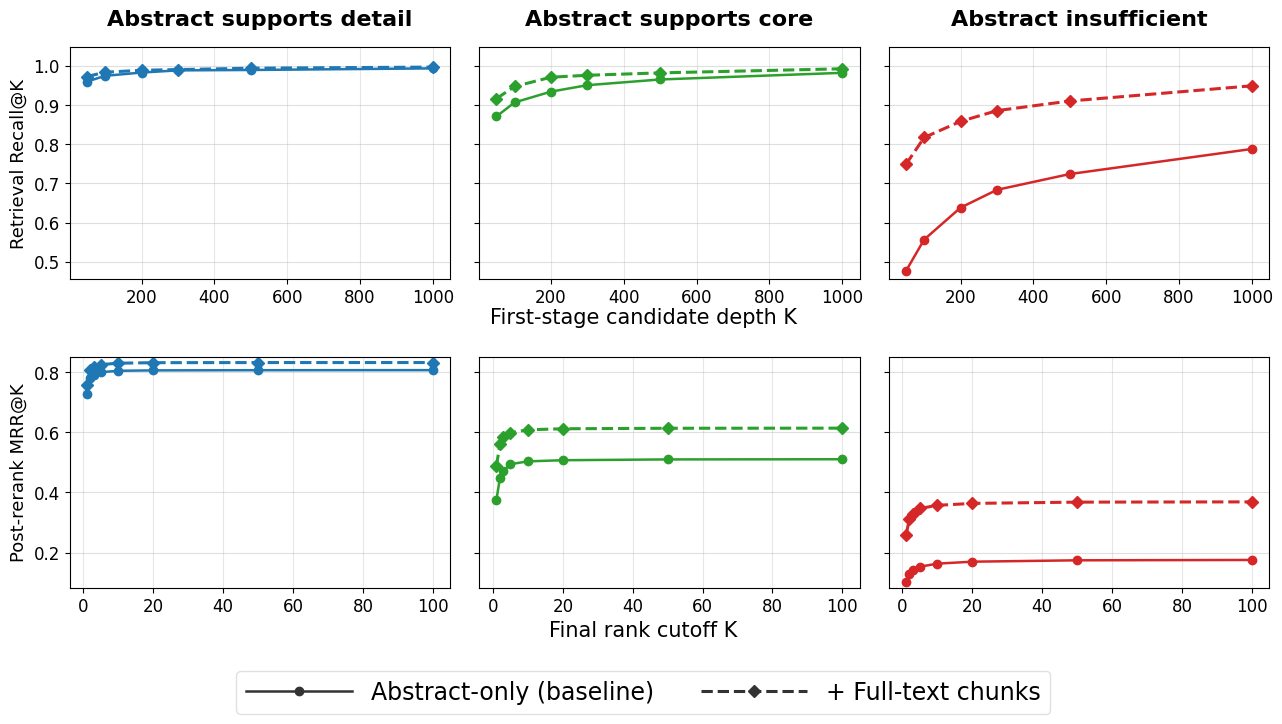


Fig 5 (has-PDF) — by evidence level:
  Level                           n   R@100 base   R@100 +chk   R@1000 base   R@1000 +chk  MRR@10 base  MRR@10 +chk
  Abstract supports detail      707       0.9738       0.9873        0.9929        0.9972       0.8015       0.8435
  Abstract supports core        585       0.9105       0.9749        0.9855        0.9977       0.5054       0.6360
  Abstract insufficient         350       0.5507       0.8543        0.7838        0.9719       0.1606       0.3853

Fig S5 (all claims) — by evidence level:
  Level                           n   R@100 base   R@100 +chk   R@1000 base   R@1000 +chk  MRR@10 base  MRR@10 +chk
  Abstract supports detail      816       0.9743       0.9835        0.9933        0.9965       0.8033       0.8285
  Abstract supports core        654       0.9065       0.9471        0.9819        0.9922       0.5028       0.6076
  Abstract insufficient         387       0.5566       0.8170        0.7877        0.9488       0.1636      

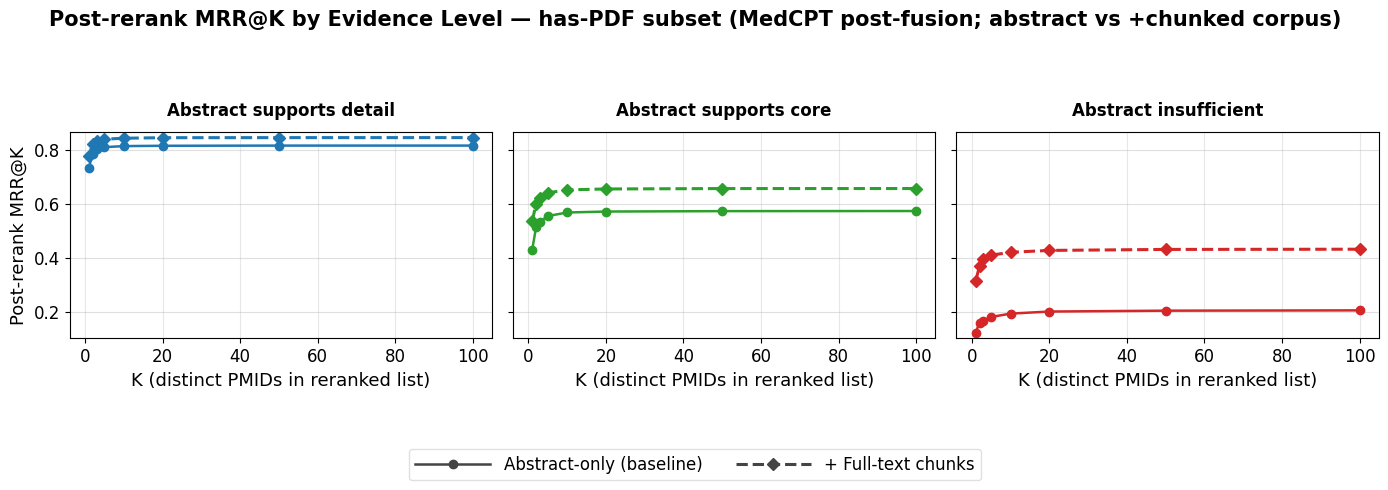

Saved: /Users/yun/develop/dictycite/output/workflow_frida_7a_public_goldset_chunked_v2_rerank_medcpt/figures/fig_s5_evidence_level_retrieval_recall_rerank_mrr_all_medcpt.png


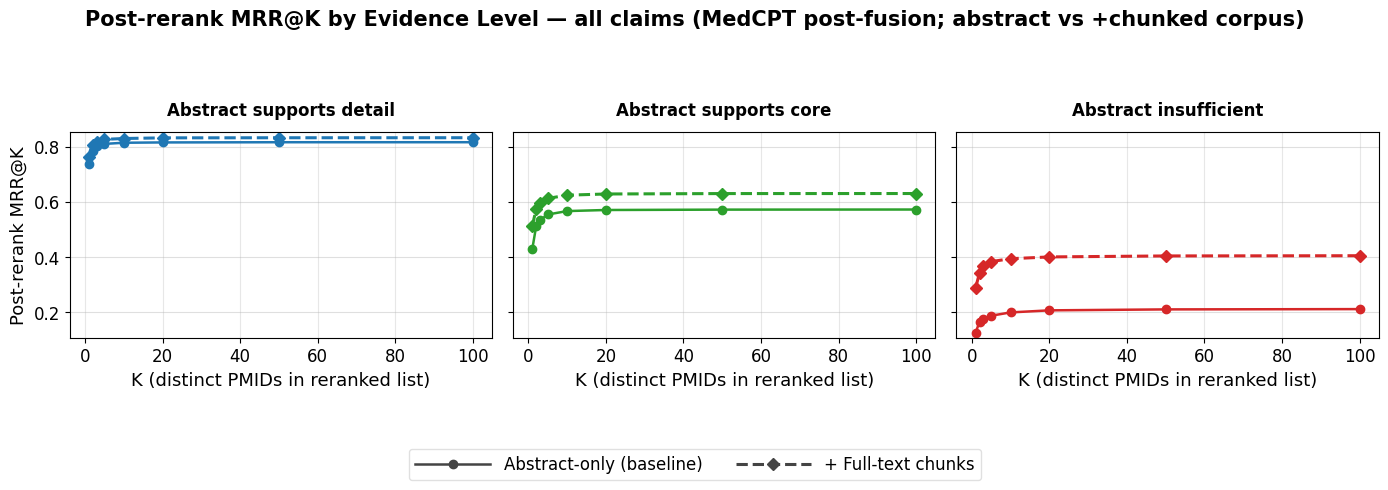


Fig 5 MedCPT (has-PDF) — by evidence level:
  Level                           n   R@100 base   R@100 +chk   R@1000 base   R@1000 +chk  MRR@10 base  MRR@10 +chk
  Abstract supports detail      707       0.9738       0.9873        0.9929        0.9972       0.8139       0.8430
  Abstract supports core        585       0.9105       0.9749        0.9855        0.9977       0.5679       0.6518
  Abstract insufficient         350       0.5507       0.8543        0.7838        0.9719       0.1934       0.4206

Fig S5 MedCPT (all claims) — by evidence level:
  Level                           n   R@100 base   R@100 +chk   R@1000 base   R@1000 +chk  MRR@10 base  MRR@10 +chk
  Abstract supports detail      816       0.9743       0.9835        0.9933        0.9965       0.8140       0.8293
  Abstract supports core        654       0.9065       0.9471        0.9819        0.9922       0.5665       0.6241
  Abstract insufficient         387       0.5566       0.8170        0.7877        0.9488     

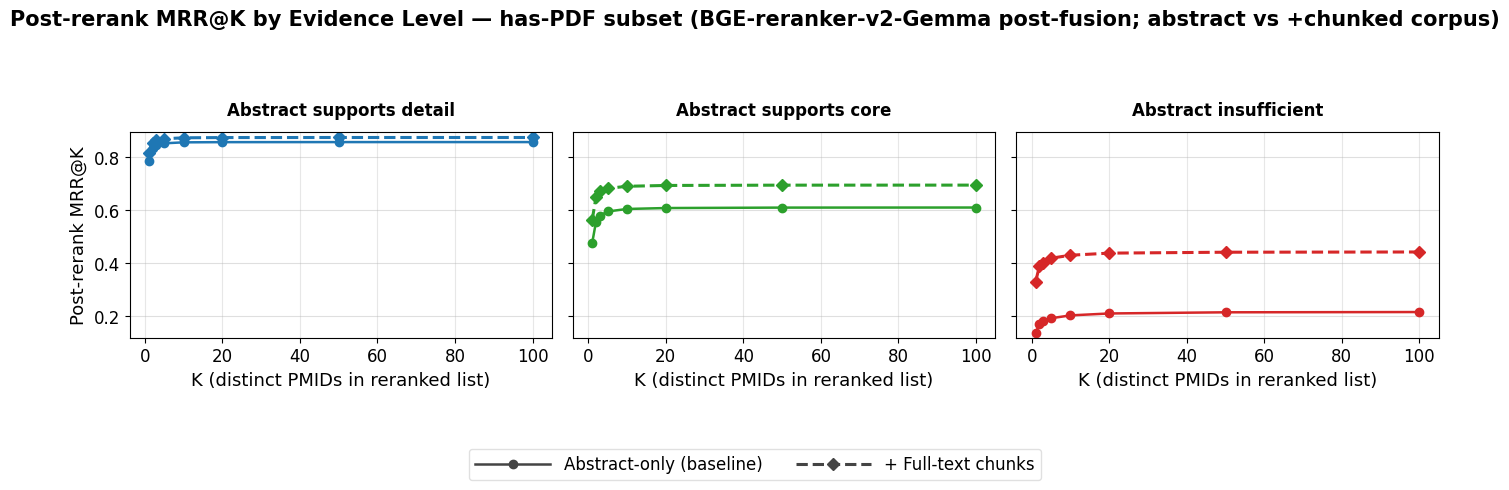

Saved: /Users/yun/develop/dictycite/output/workflow_frida_7a_public_goldset_chunked_v2_rerank_gemma/figures/fig_s5_evidence_level_retrieval_recall_rerank_mrr_all_gemma.png


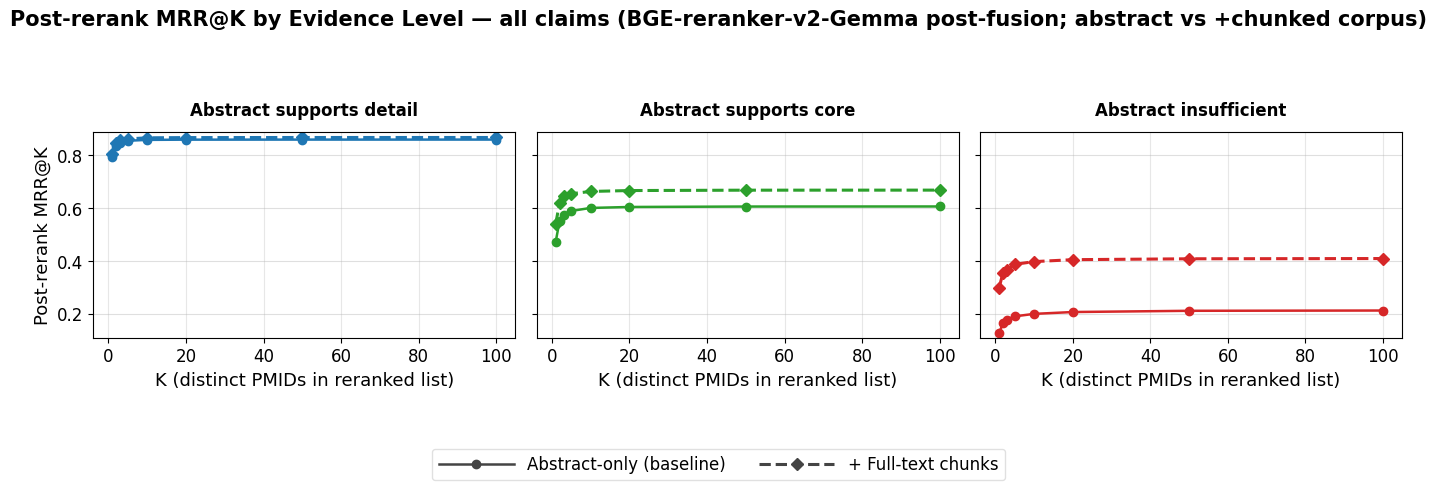


Fig 5 Gemma (has-PDF) — by evidence level:
  Level                           n   R@100 base   R@100 +chk   R@1000 base   R@1000 +chk  MRR@10 base  MRR@10 +chk
  Abstract supports detail      707       0.9738       0.9873        0.9929        0.9972       0.8567       0.8738
  Abstract supports core        585       0.9105       0.9749        0.9855        0.9977       0.6049       0.6906
  Abstract insufficient         350       0.5507       0.8543        0.7838        0.9719       0.2028       0.4301

Fig S5 Gemma (all claims) — by evidence level:
  Level                           n   R@100 base   R@100 +chk   R@1000 base   R@1000 +chk  MRR@10 base  MRR@10 +chk
  Abstract supports detail      816       0.9743       0.9835        0.9933        0.9965       0.8580       0.8659
  Abstract supports core        654       0.9065       0.9471        0.9819        0.9922       0.6009       0.6632
  Abstract insufficient         387       0.5566       0.8170        0.7877        0.9488       

In [154]:
chunked_workflow_dir = base_dir / "output" / "workflow_frida_7a_public_goldset_chunked_v2"
# Post-RRF under `rerank/post_rerank_fusion/` (pool R300/H300, k=60). The per-query CSV holds
# per-query metrics (AP@10, R@K, …); Fig 5 / S6 need the paired fused **run** TSV for rankings.
chunked_rerank_per_query_csv = (
    chunked_workflow_dir
    / "rerank"
    / "post_rerank_fusion"
    / "per_query"
    / f"{splits[0]}_rrf_poolR300_poolH300_k60.csv"
)
chunked_rerank_path = (
    chunked_workflow_dir
    / "rerank"
    / "post_rerank_fusion"
    / "runs"
    / f"best_rrf_{splits[0]}_top5000_rrf_poolR300_poolH300_k60.tsv"
)
chunked_retrieval_path = (
    chunked_workflow_dir
    / "retrieval" / "fusion" / "runs"
    / f"best_rrf_{splits[0]}_top5000.tsv"
)
baseline_retrieval_path = (
    workflow_dir
    / "retrieval" / "fusion" / "runs"
    / f"best_rrf_{splits[0]}_top5000.tsv"
)

_missing = [p for p in (chunked_rerank_path, chunked_retrieval_path, baseline_retrieval_path) if not p.exists()]
if _missing:
    for p in _missing:
        print(f"Missing run for Fig 5: {p}")
    print("Skipping Fig 5 / Fig S3.")
else:
    def _load_pmid_dedup(path: Path) -> dict[str, list[str]]:
        """Load run TSV, split docno on '#' to get PMID, dedupe per qid (first wins)."""
        run_df = _load_run(path)
        qcol, dcol = run_df.columns.tolist()
        out: dict[str, list[str]] = {}
        for qid, group in run_df.groupby(qcol, sort=False):
            seen: set[str] = set()
            ordered: list[str] = []
            for docno in group[dcol]:
                pmid = str(docno).split("#", 1)[0]
                if pmid in seen:
                    continue
                seen.add(pmid)
                ordered.append(pmid)
            out[str(qid)] = ordered
        return out

    # Retrieval-stage hybrid fusion runs (top of pipeline, before CE).
    run_retrieval_base    = _load_pmid_dedup(baseline_retrieval_path)
    run_retrieval_chunked = _load_pmid_dedup(chunked_retrieval_path)
    # Post-rerank-fusion run (after CE + RRF). Baseline already in run_docs from §12;
    # rebuild via the same dedup helper so the two paths share preprocessing.
    run_rerank_base    = _load_pmid_dedup(
        rerank_dir / "post_rerank_fusion_snippet" / "runs"
        / f"best_rrf_{splits[0]}_top5000_rrf_poolR200_poolH200_k60.tsv"
    )
    run_rerank_chunked = _load_pmid_dedup(chunked_rerank_path)

    if not chunked_rerank_per_query_csv.is_file():
        print(
            f"Note: per-query metrics CSV not found (expected next to this run): {chunked_rerank_per_query_csv}"
        )
    else:
        print(f"Paired per-query metrics CSV: {chunked_rerank_per_query_csv}")

    print(
        f"Loaded runs (qids): "
        f"retrieval base={len(run_retrieval_base)}  chunked={len(run_retrieval_chunked)};  "
        f"rerank base={len(run_rerank_base)}  chunked={len(run_rerank_chunked)}"
    )

    # ----- Fig 5 / Fig S3: x-axis K grids (retrieval recall vs rerank MRR) -----
    # Upper row stops at max K listed; extend/cap the list as needed.
    KS_RECALL_RETRIEVAL = [50, 100, 200, 300, 500, 1000]
    KS_MRR_RERANK = [1, 2, 3, 5, 10, 20, 50, 100]

    def _per_level_curve(
        per_level_qrels: dict[str, dict[str, set[str]]],
        run_a: dict[str, list[str]],
        run_b: dict[str, list[str]],
        ks: list[int],
        metric: str,  # "recall" or "mrr"
    ) -> tuple[dict[str, list[float]], dict[str, list[float]], dict[str, int]]:
        score_fn = _recall_at_k if metric == "recall" else _mrr_at_k
        curve_a: dict[str, list[float]] = {lvl: [] for lvl in levels}
        curve_b: dict[str, list[float]] = {lvl: [] for lvl in levels}
        n_per: dict[str, int] = {lvl: 0 for lvl in levels}
        for lvl in levels:
            lvl_qrels = per_level_qrels.get(lvl, {})
            qids_lvl = [qid for qid in lvl_qrels if qid in run_a and qid in run_b]
            if not qids_lvl:
                curve_a[lvl] = [0.0] * len(ks)
                curve_b[lvl] = [0.0] * len(ks)
                continue
            n_per[lvl] = len(qids_lvl)
            for k in ks:
                va, vb = [], []
                for qid in qids_lvl:
                    rels_set = lvl_qrels[qid]
                    if not rels_set:
                        continue
                    va.append(score_fn(run_a[qid], rels_set, k))
                    vb.append(score_fn(run_b[qid], rels_set, k))
                curve_a[lvl].append(float(np.mean(va)) if va else 0.0)
                curve_b[lvl].append(float(np.mean(vb)) if vb else 0.0)
        return curve_a, curve_b, n_per

    BASELINE_LABEL = "Abstract-only (baseline)"
    CHUNKED_LABEL  = "+ Full-text chunks"
    BASELINE_STYLE = {"linestyle": "-",  "linewidth": 1.8, "marker": "o", "markersize": 6}
    CHUNKED_STYLE  = {"linestyle": "--", "linewidth": 2.2, "marker": "D", "markersize": 6}

    # ----- Fig 5 / Fig S3: 2×3 retrieval + rerank overlay — layout knobs (edit here) -----
    # Figure size (inches, width × height).
    FIG5_OVERLAY_FIGSIZE = (13.0, 7.8)
    # Column titles = evidence level labels on the top row only. `pad` = extra space below
    # that title before the plot (matplotlib points; larger ⇒ more “air” under the title).
    FIG5_OVERLAY_COL_TITLE_FONTSIZE = 16
    FIG5_OVERLAY_COL_TITLE_PAD = 16.0
    # Fig S3 only: `suptitle` string is passed in code; these control its look and clearance.
    # Lower `FIG5_OVERLAY_RECT_TOP_WITH_SUPTITLE` ⇒ more vertical gap between suptitle and panels.
    FIG5_OVERLAY_SUPTITLE_FONTSIZE = 17
    FIG5_OVERLAY_SUPTITLE_Y = 0.995
    # `tight_layout(..., rect=[left, bottom, right, top])`: subplot area inside the figure.
    FIG5_OVERLAY_RECT_LEFT = 0.0
    FIG5_OVERLAY_RECT_BOTTOM = 0.16
    FIG5_OVERLAY_RECT_RIGHT = 1.0
    FIG5_OVERLAY_RECT_TOP_NO_SUPTITLE = 0.98
    FIG5_OVERLAY_RECT_TOP_WITH_SUPTITLE = 0.90
    # `h_pad` / `pad` = extra spacing between subplot rows/cols (matplotlib “padding” units).
    FIG5_OVERLAY_H_PAD = 3.6
    FIG5_OVERLAY_PAD = 1.2
    # Shared x-axis semantics (one label per row; drawn after `tight_layout`).
    FIG5_OVERLAY_LABEL_UPPER = "First-stage candidate depth K"
    FIG5_OVERLAY_LABEL_UPPER_FONTSIZE = 15
    FIG5_OVERLAY_LABEL_LOWER = "Final rank cutoff K"
    FIG5_OVERLAY_LABEL_LOWER_FONTSIZE = 15
    # `supxlabel(..., y=…)`: vertical position in figure coordinates (raise/lower vs tick labels).
    FIG5_OVERLAY_SUPXLABEL_Y = 0.15
    # Figure-level legend under the bottom row.
    FIG5_OVERLAY_LEGEND_FONTSIZE = 17
    FIG5_OVERLAY_LEGEND_HANDLELENGTH = 4.5
    FIG5_OVERLAY_LEGEND_BBOX_X = 0.5
    FIG5_OVERLAY_LEGEND_BBOX_Y = 0.04
    FIG5_OVERLAY_LEGEND_NCOL = 2
    # Raster export.
    FIG5_OVERLAY_DPI = 150

    def _plot_retrieval_rerank_overlay(
        per_level_qrels: dict[str, dict[str, set[str]]],
        suptitle: str | None,
        out_path: Path,
        *,
        r_ret_base: dict[str, list[str]],
        r_ret_chunked: dict[str, list[str]],
        r_rr_base: dict[str, list[str]],
        r_rr_chunked: dict[str, list[str]],
        legend_fontsize: int = FIG5_OVERLAY_LEGEND_FONTSIZE,
    ) -> dict[str, int]:
        rec_base, rec_chk, n_per = _per_level_curve(
            per_level_qrels, r_ret_base, r_ret_chunked,
            KS_RECALL_RETRIEVAL, metric="recall",
        )
        mrr_base, mrr_chk, _ = _per_level_curve(
            per_level_qrels, r_rr_base, r_rr_chunked,
            KS_MRR_RERANK, metric="mrr",
        )

        all_rec = [v for d in (rec_base, rec_chk) for vals in d.values() for v in vals]
        all_mrr = [v for d in (mrr_base, mrr_chk) for vals in d.values() for v in vals]
        y_min_r = max(0.0, min(all_rec) - 0.02) if all_rec else 0.0
        _top_r = max(all_rec) if all_rec else 1.0
        if _top_r > 0.94:
            y_max_r = min(1.12, _top_r + 0.05)
        else:
            y_max_r = min(1.0, _top_r + 0.02)
        y_min_m = max(0.0, min(all_mrr) - 0.02) if all_mrr else 0.0
        y_max_m = min(1.0, max(all_mrr) + 0.02) if all_mrr else 1.0

        fig, axes = plt.subplots(2, 3, figsize=FIG5_OVERLAY_FIGSIZE)
        for idx, lvl in enumerate(levels):
            color = EVIDENCE_FIG3_COLORS.get(lvl, "#444444")
            col_title = EVIDENCE_FIG3_LABELS.get(lvl, lvl)

            ax_r = axes[0, idx]
            ax_r.plot(KS_RECALL_RETRIEVAL, rec_base[lvl], color=color, **BASELINE_STYLE)
            ax_r.plot(KS_RECALL_RETRIEVAL, rec_chk[lvl],  color=color, **CHUNKED_STYLE)
            ax_r.set_title(
                col_title,
                fontweight="bold",
                fontsize=FIG5_OVERLAY_COL_TITLE_FONTSIZE,
                pad=FIG5_OVERLAY_COL_TITLE_PAD,
            )
            ax_r.set_ylim(y_min_r, y_max_r)
            ax_r.set_ylabel("Retrieval Recall@K" if idx == 0 else "")
            if idx != 0:
                ax_r.tick_params(axis="y", labelleft=False)
            ax_r.grid(True, axis="y", alpha=0.4)
            ax_r.grid(True, axis="x", alpha=0.3)

            ax_m = axes[1, idx]
            ax_m.plot(KS_MRR_RERANK, mrr_base[lvl], color=color, **BASELINE_STYLE)
            ax_m.plot(KS_MRR_RERANK, mrr_chk[lvl],  color=color, **CHUNKED_STYLE)
            ax_m.set_ylim(y_min_m, y_max_m)
            ax_m.set_ylabel("Post-rerank MRR@K" if idx == 0 else "")
            if idx != 0:
                ax_m.tick_params(axis="y", labelleft=False)
            ax_m.grid(True, axis="y", alpha=0.4)
            ax_m.grid(True, axis="x", alpha=0.3)

        # Non-degenerate segments so linestyle/-- renders in the legend (single-point
        # Line2D handles often draw as solid). Match plot dash style from *_STYLE.
        legend_handles = [
            Line2D(
                [0, 1],
                [0, 0],
                color="#333333",
                label=BASELINE_LABEL,
                linestyle=BASELINE_STYLE["linestyle"],
                linewidth=BASELINE_STYLE["linewidth"],
                marker=BASELINE_STYLE["marker"],
                markersize=BASELINE_STYLE["markersize"],
            ),
            Line2D(
                [0, 1],
                [0, 0],
                color="#333333",
                label=CHUNKED_LABEL,
                linestyle=CHUNKED_STYLE["linestyle"],
                linewidth=CHUNKED_STYLE["linewidth"],
                marker=CHUNKED_STYLE["marker"],
                markersize=CHUNKED_STYLE["markersize"],
            ),
        ]
        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(FIG5_OVERLAY_LEGEND_BBOX_X, FIG5_OVERLAY_LEGEND_BBOX_Y),
            ncol=FIG5_OVERLAY_LEGEND_NCOL,
            fontsize=legend_fontsize,
            frameon=True,
            edgecolor="0.85",
            handlelength=FIG5_OVERLAY_LEGEND_HANDLELENGTH,
        )
        _layout_top = FIG5_OVERLAY_RECT_TOP_NO_SUPTITLE
        if suptitle:
            fig.suptitle(
                suptitle,
                fontsize=FIG5_OVERLAY_SUPTITLE_FONTSIZE,
                fontweight="bold",
                y=FIG5_OVERLAY_SUPTITLE_Y,
            )
            _layout_top = FIG5_OVERLAY_RECT_TOP_WITH_SUPTITLE
        # Extra h_pad separates rows so the between-row caption does not sit on top
        # of the upper panels' x tick labels; larger bottom rect + supxlabel y for
        # the lower caption vs bottom x ticks.
        plt.tight_layout(
            rect=[
                FIG5_OVERLAY_RECT_LEFT,
                FIG5_OVERLAY_RECT_BOTTOM,
                FIG5_OVERLAY_RECT_RIGHT,
                _layout_top,
            ],
            h_pad=FIG5_OVERLAY_H_PAD,
            pad=FIG5_OVERLAY_PAD,
        )
        # One x-axis caption per row (avoid repeating the same label on every column).
        pos_hi_bottom = axes[0, 1].get_position().y0
        pos_lo_top = axes[1, 1].get_position().y1
        y_mid_rows = (pos_hi_bottom + pos_lo_top) / 2
        fig.text(
            0.5,
            y_mid_rows,
            FIG5_OVERLAY_LABEL_UPPER,
            ha="center",
            va="center",
            fontsize=FIG5_OVERLAY_LABEL_UPPER_FONTSIZE,
        )
        fig.supxlabel(
            FIG5_OVERLAY_LABEL_LOWER,
            fontsize=FIG5_OVERLAY_LABEL_LOWER_FONTSIZE,
            y=FIG5_OVERLAY_SUPXLABEL_Y,
        )
        plt.savefig(out_path, dpi=FIG5_OVERLAY_DPI, bbox_inches="tight")
        print("Saved:", out_path)
        plt.show()
        return n_per

    # ----- Fig 5 alt: 1×3 MRR-only panels (MedCPT / Gemma paths below) -----
    FIG5_ALT_FIGSIZE = (14.0, 4.2)
    FIG5_ALT_COL_TITLE_FONTSIZE = 12
    FIG5_ALT_COL_TITLE_PAD = 12.0
    FIG5_ALT_SUPTITLE_FONTSIZE = 15
    FIG5_ALT_SUPTITLE_Y = 1.02
    FIG5_ALT_RECT = (0.0, 0.08, 1.0, 0.92)  # left, bottom, right, top for tight_layout
    FIG5_ALT_XLABEL = "K (distinct PMIDs in reranked list)"
    FIG5_ALT_LEGEND_FONTSIZE = 12
    FIG5_ALT_LEGEND_HANDLELENGTH = 4.5
    FIG5_ALT_LEGEND_BBOX_X = 0.5
    FIG5_ALT_LEGEND_BBOX_Y = -0.12
    FIG5_ALT_LEGEND_NCOL = 2
    FIG5_ALT_DPI = 150

    def _plot_alt_rerank_mrr_row_only(
        per_level_qrels: dict[str, dict[str, set[str]]],
        suptitle: str,
        out_path: Path,
        *,
        r_rr_base: dict[str, list[str]],
        r_rr_chunked: dict[str, list[str]],
    ) -> dict[str, int]:
        """1×3 panels: post-rerank MRR@K only for an alternate CE (retrieval same as Fig 5 / S5)."""
        mrr_base, mrr_chk, n_per = _per_level_curve(
            per_level_qrels, r_rr_base, r_rr_chunked,
            KS_MRR_RERANK, metric="mrr",
        )
        all_mrr = [v for d in (mrr_base, mrr_chk) for vals in d.values() for v in vals]
        y_min_m = max(0.0, min(all_mrr) - 0.02) if all_mrr else 0.0
        y_max_m = min(1.0, max(all_mrr) + 0.02) if all_mrr else 1.0

        fig, axes = plt.subplots(1, 3, figsize=FIG5_ALT_FIGSIZE)
        for idx, lvl in enumerate(levels):
            color = EVIDENCE_FIG3_COLORS.get(lvl, "#444444")
            col_title = EVIDENCE_FIG3_LABELS.get(lvl, lvl)
            ax_m = axes[idx]
            ax_m.plot(KS_MRR_RERANK, mrr_base[lvl], color=color, **BASELINE_STYLE)
            ax_m.plot(KS_MRR_RERANK, mrr_chk[lvl], color=color, **CHUNKED_STYLE)
            ax_m.set_title(
                col_title,
                fontweight="bold",
                fontsize=FIG5_ALT_COL_TITLE_FONTSIZE,
                pad=FIG5_ALT_COL_TITLE_PAD,
            )
            ax_m.set_ylim(y_min_m, y_max_m)
            ax_m.set_ylabel("Post-rerank MRR@K" if idx == 0 else "")
            if idx != 0:
                ax_m.tick_params(axis="y", labelleft=False)
            ax_m.set_xlabel(FIG5_ALT_XLABEL)
            ax_m.grid(True, axis="y", alpha=0.4)
            ax_m.grid(True, axis="x", alpha=0.3)

        legend_handles = [
            Line2D(
                [0, 1],
                [0, 0],
                color="#444444",
                label=BASELINE_LABEL,
                linestyle=BASELINE_STYLE["linestyle"],
                linewidth=BASELINE_STYLE["linewidth"],
                marker=BASELINE_STYLE["marker"],
                markersize=BASELINE_STYLE["markersize"],
            ),
            Line2D(
                [0, 1],
                [0, 0],
                color="#444444",
                label=CHUNKED_LABEL,
                linestyle=CHUNKED_STYLE["linestyle"],
                linewidth=CHUNKED_STYLE["linewidth"],
                marker=CHUNKED_STYLE["marker"],
                markersize=CHUNKED_STYLE["markersize"],
            ),
        ]
        fig.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(FIG5_ALT_LEGEND_BBOX_X, FIG5_ALT_LEGEND_BBOX_Y),
            ncol=FIG5_ALT_LEGEND_NCOL,
            fontsize=FIG5_ALT_LEGEND_FONTSIZE,
            frameon=True,
            edgecolor="0.85",
            handlelength=FIG5_ALT_LEGEND_HANDLELENGTH,
        )
        fig.suptitle(
            suptitle,
            fontsize=FIG5_ALT_SUPTITLE_FONTSIZE,
            fontweight="bold",
            y=FIG5_ALT_SUPTITLE_Y,
        )
        plt.tight_layout(rect=list(FIG5_ALT_RECT))
        plt.savefig(out_path, dpi=FIG5_ALT_DPI, bbox_inches="tight")
        print("Saved:", out_path)
        plt.show()
        return n_per

    n_hp = _plot_retrieval_rerank_overlay(
        level_qrels_haspdf,
        suptitle=None,
        out_path=paper_figures_dir / "fig5_evidence_level_retrieval_recall_rerank_mrr_haspdf.png",
        r_ret_base=run_retrieval_base,
        r_ret_chunked=run_retrieval_chunked,
        r_rr_base=run_rerank_base,
        r_rr_chunked=run_rerank_chunked,
    )
    n_all = _plot_retrieval_rerank_overlay(
        level_qrels,
        suptitle=None,
        out_path=paper_figures_dir / "fig_s3_evidence_level_full_goldset.png",
        r_ret_base=run_retrieval_base,
        r_ret_chunked=run_retrieval_chunked,
        r_rr_base=run_rerank_base,
        r_rr_chunked=run_rerank_chunked,
    )

    # Caption numbers: retrieval Recall@1000 + rerank MRR@10, per evidence level.
    def _caption_table(
        per_level_qrels,
        n_per,
        label,
        *,
        rr_base=None,
        rr_chunked=None,
    ):
        rb = rr_base if rr_base is not None else run_rerank_base
        rc = rr_chunked if rr_chunked is not None else run_rerank_chunked
        rec_base, rec_chk, _ = _per_level_curve(
            per_level_qrels, run_retrieval_base, run_retrieval_chunked,
            [100, 1000], metric="recall",
        )
        mrr_base, mrr_chk, _ = _per_level_curve(
            per_level_qrels, rb, rc,
            [10], metric="mrr",
        )
        print(f"\n{label} — by evidence level:")
        print(f"  {'Level':28s} {'n':>4s}  "
              f"{'R@100 base':>11s}  {'R@100 +chk':>11s}  "
              f"{'R@1000 base':>12s}  {'R@1000 +chk':>12s}  "
              f"{'MRR@10 base':>11s}  {'MRR@10 +chk':>11s}")
        for lvl in levels:
            n = n_per.get(lvl, 0)
            print(f"  {EVIDENCE_FIG3_LABELS.get(lvl, lvl):28s} {n:4d}  "
                  f"{rec_base[lvl][0]:11.4f}  {rec_chk[lvl][0]:11.4f}  "
                  f"{rec_base[lvl][1]:12.4f}  {rec_chk[lvl][1]:12.4f}  "
                  f"{mrr_base[lvl][0]:11.4f}  {mrr_chk[lvl][0]:11.4f}")

    _caption_table(level_qrels_haspdf, n_hp, "Fig 5 (has-PDF)")
    _caption_table(level_qrels,        n_all, "Fig S3 (all claims)")

    # Same evidence layout, MedCPT post-rerank fusion (abstract vs chunked v2).
    def _fig5_pick_post_fusion_tsv(wf: Path, split: str) -> Path | None:
        for sub in ("post_rerank_fusion_snippet", "post_rerank_fusion"):
            rd = wf / "rerank" / sub / "runs"
            if not rd.is_dir():
                continue
            cand = sorted(rd.glob(f"best_rrf_{split}_top5000*.tsv"))
            if cand:
                return cand[0]
        return None

    _wf_medcpt_vega = base_dir / "output" / "workflow_vega_7a_public_goldset_rerank_medcpt"
    _wf_medcpt_frida = base_dir / "output" / "workflow_frida_7a_public_goldset_chunked_v2_rerank_medcpt"
    _med_rr_v = _fig5_pick_post_fusion_tsv(_wf_medcpt_vega, splits[0])
    _med_rr_f = _fig5_pick_post_fusion_tsv(_wf_medcpt_frida, splits[0])
    if _med_rr_v and _med_rr_f and _med_rr_v.is_file() and _med_rr_f.is_file():
        _med_fig_vega = _wf_medcpt_vega / "figures"
        _med_fig_frida = _wf_medcpt_frida / "figures"
        _med_fig_vega.mkdir(parents=True, exist_ok=True)
        _med_fig_frida.mkdir(parents=True, exist_ok=True)
        run_rerank_base_medcpt = _load_pmid_dedup(_med_rr_v)
        run_rerank_chunked_medcpt = _load_pmid_dedup(_med_rr_f)
        n_hp_m = _plot_alt_rerank_mrr_row_only(
            level_qrels_haspdf,
            suptitle=(
                "Post-rerank MRR@K by Evidence Level — has-PDF subset "
                "(MedCPT post-fusion; abstract vs +chunked corpus)"
            ),
            out_path=_med_fig_vega / "fig5_evidence_level_retrieval_recall_rerank_mrr_haspdf_medcpt.png",
            r_rr_base=run_rerank_base_medcpt,
            r_rr_chunked=run_rerank_chunked_medcpt,
        )
        n_all_m = _plot_alt_rerank_mrr_row_only(
            level_qrels,
            suptitle=(
                "Post-rerank MRR@K by Evidence Level — all claims "
                "(MedCPT post-fusion; abstract vs +chunked corpus)"
            ),
            out_path=_med_fig_frida / "fig_s3_evidence_level_full_goldset_medcpt.png",
            r_rr_base=run_rerank_base_medcpt,
            r_rr_chunked=run_rerank_chunked_medcpt,
        )
        _caption_table(
            level_qrels_haspdf,
            n_hp_m,
            "Fig 5 MedCPT (has-PDF)",
            rr_base=run_rerank_base_medcpt,
            rr_chunked=run_rerank_chunked_medcpt,
        )
        _caption_table(
            level_qrels,
            n_all_m,
            "Fig S3 MedCPT (all claims)",
            rr_base=run_rerank_base_medcpt,
            rr_chunked=run_rerank_chunked_medcpt,
        )
    else:
        print(
            "Skipping Fig 5 / Fig S3 MedCPT overlays: need post-fusion TSVs under\n"
            f"  {_wf_medcpt_vega!s}\n  {_wf_medcpt_frida!s}"
        )

    _wf_gemma_abs = base_dir / "output" / "workflow_frida_7a_public_goldset_rerank_gemma"
    _wf_gemma_chunk = base_dir / "output" / "workflow_frida_7a_public_goldset_chunked_v2_rerank_gemma"
    _gem_rr_v = _fig5_pick_post_fusion_tsv(_wf_gemma_abs, splits[0])
    _gem_rr_f = _fig5_pick_post_fusion_tsv(_wf_gemma_chunk, splits[0])
    if _gem_rr_v and _gem_rr_f and _gem_rr_v.is_file() and _gem_rr_f.is_file():
        _gem_fig_abs = _wf_gemma_abs / "figures"
        _gem_fig_chunk = _wf_gemma_chunk / "figures"
        _gem_fig_abs.mkdir(parents=True, exist_ok=True)
        _gem_fig_chunk.mkdir(parents=True, exist_ok=True)
        run_rerank_base_gemma = _load_pmid_dedup(_gem_rr_v)
        run_rerank_chunked_gemma = _load_pmid_dedup(_gem_rr_f)
        n_hp_g = _plot_alt_rerank_mrr_row_only(
            level_qrels_haspdf,
            suptitle=(
                "Post-rerank MRR@K by Evidence Level — has-PDF subset "
                "(BGE-Gemma post-fusion; abstract vs +chunked corpus)"
            ),
            out_path=_gem_fig_abs / "fig5_evidence_level_retrieval_recall_rerank_mrr_haspdf_gemma.png",
            r_rr_base=run_rerank_base_gemma,
            r_rr_chunked=run_rerank_chunked_gemma,
        )
        n_all_g = _plot_alt_rerank_mrr_row_only(
            level_qrels,
            suptitle=(
                "Post-rerank MRR@K by Evidence Level — all claims "
                "(BGE-Gemma post-fusion; abstract vs +chunked corpus)"
            ),
            out_path=_gem_fig_chunk / "fig_s3_evidence_level_full_goldset_gemma.png",
            r_rr_base=run_rerank_base_gemma,
            r_rr_chunked=run_rerank_chunked_gemma,
        )
        _caption_table(
            level_qrels_haspdf,
            n_hp_g,
            "Fig 5 Gemma (has-PDF)",
            rr_base=run_rerank_base_gemma,
            rr_chunked=run_rerank_chunked_gemma,
        )
        _caption_table(
            level_qrels,
            n_all_g,
            "Fig S3 Gemma (all claims)",
            rr_base=run_rerank_base_gemma,
            rr_chunked=run_rerank_chunked_gemma,
        )
    else:
        print(
            "Skipping Fig 5 / Fig S3 Gemma overlays: need post-fusion TSVs under\n"
            f"  {_wf_gemma_abs!s}\n  {_wf_gemma_chunk!s}"
        )

## 15. Fig S4 — Per-query Δ MRR@10 (chunked − abstract) by evidence level

*Paper role:* supplementary Fig S4. Decomposes the aggregate MRR@10 lift in
Fig 5 into helped / hurt / near tie (|Δ|≤0.025) per query, one panel per evidence level,
on the has-PDF subset using BGE-reranker-v2-m3 (same runs as Fig 5 lower row).
Shows whether the +22 pp average on `abstract_insufficient` comes from many
small gains or a few outliers, and whether chunks ever *hurt* on the buckets
where the abstract was already enough.

Per-query MRR@10 Δ (chunked − abstract) by evidence level (has-PDF):
  Abstract supports detail   n=707  helped 111 (15.7%, mean Δ +0.5060)  near tie 526  hurt 70 (9.9%, mean Δ -0.3777)  agg Δ +0.0421
  Abstract supports core     n=585  helped 203 (34.7%, mean Δ +0.5108)  near tie 288  hurt 94 (16.1%, mean Δ -0.2903)  agg Δ +0.1306
  Abstract insufficient      n=350  helped 164 (46.9%, mean Δ +0.5272)  near tie 158  hurt 28 (8.0%, mean Δ -0.2778)  agg Δ +0.2248
Saved: /Users/yun/develop/dictycite/output/paper_figures/fig_s6_per_query_chunked_delta_haspdf.png


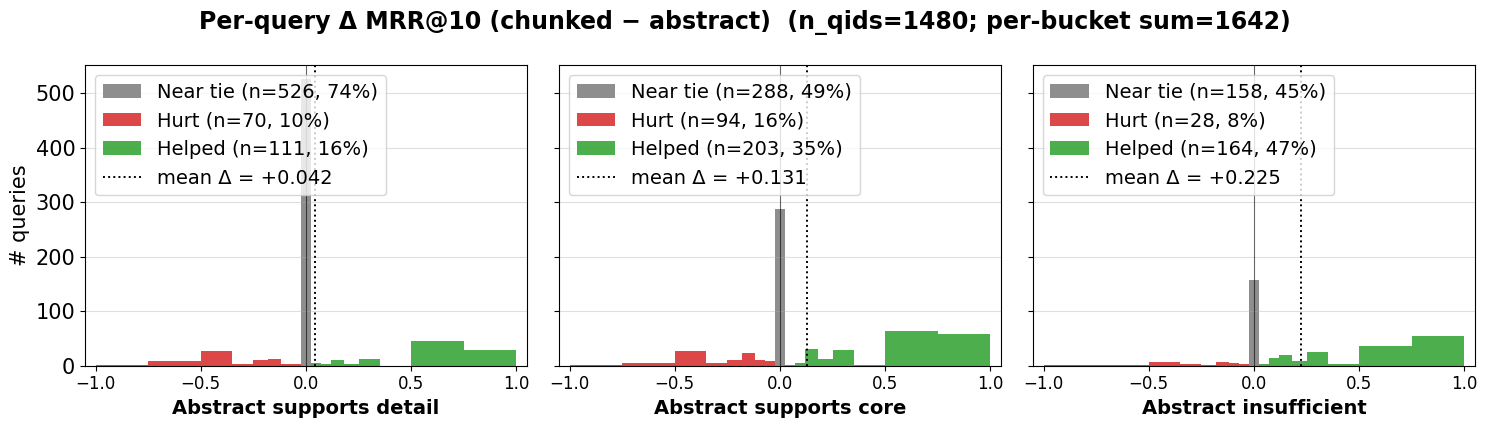

In [157]:
if all(name in globals() for name in ("run_rerank_base", "run_rerank_chunked",
                                       "level_qrels_haspdf", "levels")):
    FIG_S4_BINS = np.concatenate([
        np.array([-1.0, -0.75, -0.5, -0.35, -0.25, -0.18, -0.12, -0.07, -0.025]),
        np.array([0.025, 0.07, 0.12, 0.18, 0.25, 0.35, 0.5, 0.75, 1.0]),
    ])
    FIG_S4_K = 10
    FIG_S4_XLIM = (-1.05, 1.05)
    # Match Fig S2 styling (ragnarok_comparison §11): suptitle height + tight_layout top margin.
    FIG_S4_SUPTITLE_Y = 0.94

    def _fig_s4_legend_order(handles, labels):
        """Grey (near tie) first, mean Δ last — same legend ordering as Fig S2."""

        def _rank(lab: str) -> int:
            if lab.startswith("Near tie"):
                return 0
            if lab.startswith("Hurt"):
                return 1
            if lab.startswith("Helped"):
                return 2
            if lab.startswith("mean"):
                return 3
            return 9

        order = sorted(range(len(labels)), key=lambda i: _rank(labels[i]))
        return [handles[i] for i in order], [labels[i] for i in order]

    fig_s4, axes_s4 = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    print(f"Per-query MRR@{FIG_S4_K} Δ (chunked − abstract) by evidence level (has-PDF):")
    for ax, lvl in zip(axes_s4, levels):
        lvl_qrels = level_qrels_haspdf.get(lvl, {})
        qids = [q for q in lvl_qrels if q in run_rerank_base and q in run_rerank_chunked]
        if not qids:
            ax.set_visible(False)
            continue
        deltas = np.array([
            _mrr_at_k(run_rerank_chunked[q], lvl_qrels[q], FIG_S4_K)
            - _mrr_at_k(run_rerank_base[q], lvl_qrels[q], FIG_S4_K)
            for q in qids
        ])
        n_total = len(deltas)
        hurt_m = deltas < -0.025
        help_m = deltas > +0.025
        neutral_m = ~(hurt_m | help_m)
        n_helped = int(help_m.sum())
        n_hurt = int(hurt_m.sum())
        n_neutral = int(neutral_m.sum())
        mean_overall = float(deltas.mean())
        mean_help = float(deltas[help_m].mean()) if n_helped else 0.0
        mean_hurt = float(deltas[hurt_m].mean()) if n_hurt else 0.0

        print(
            f"  {EVIDENCE_FIG3_LABELS.get(lvl, lvl):26s} n={n_total}  "
            f"helped {n_helped} ({n_helped/n_total:.1%}, mean Δ +{mean_help:.4f})  "
            f"near tie {n_neutral}  "
            f"hurt {n_hurt} ({n_hurt/n_total:.1%}, mean Δ {mean_hurt:.4f})  "
            f"agg Δ {mean_overall:+.4f}"
        )

        ax.hist(
            deltas[hurt_m], bins=FIG_S4_BINS, color="#d62728", alpha=0.85,
            label=f"Hurt (n={n_hurt}, {n_hurt/n_total:.0%})",
        )
        ax.hist(
            deltas[help_m], bins=FIG_S4_BINS, color="#2ca02c", alpha=0.85,
            label=f"Helped (n={n_helped}, {n_helped/n_total:.0%})",
        )
        ax.bar(
            [0], [n_neutral], width=0.05, color="#888888", alpha=0.95,
            label=f"Near tie (n={n_neutral}, {n_neutral/n_total:.0%})",
        )
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
        ax.axvline(
            mean_overall, color="black", linestyle=":", linewidth=1.4,
            label=f"mean Δ = {mean_overall:+.3f}",
        )
        ax.set_xlabel(
            EVIDENCE_FIG3_LABELS.get(lvl, lvl),
            fontsize=14,
            fontweight="bold",
        )
        ax.set_xlim(*FIG_S4_XLIM)
        ax.grid(True, axis="y", alpha=0.4)
        ax.tick_params(axis="y", labelsize=15)
        h_leg, lab_leg = ax.get_legend_handles_labels()
        h_ord, lab_ord = _fig_s4_legend_order(h_leg, lab_leg)
        ax.legend(h_ord, lab_ord, fontsize=14, loc="upper left")

    axes_s4[0].set_ylabel("# queries", fontsize=15)
    n_pairs_haspdf = sum(len(level_qrels_haspdf.get(l, {})) for l in levels)
    n_qids_haspdf = len({q for l in levels for q in level_qrels_haspdf.get(l, {})})
    fig_s4.suptitle(
        f"Per-query Δ MRR@10 (chunked − abstract)  "
        f"(n_qids={n_qids_haspdf}; per-bucket sum={n_pairs_haspdf})",
        fontsize=17,
        fontweight="bold",
        y=FIG_S4_SUPTITLE_Y,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    fig_s4_path = paper_figures_dir / "fig_s4_per_query_chunked_delta_haspdf.png"
    plt.savefig(fig_s4_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_s4_path}")
    plt.show()
else:
    print("Skipping Fig S4: required §14 variables not in scope.")

## 16. Top gain / top hurt queries from chunked corpus (diagnostic CSV)

*Diagnostic.* For each evidence level on the has-PDF subset, export the top-N
queries by Δ MRR@10 (chunked − abstract), helped and hurt, with query text
and the relevant PMID's abstract. For qualitative inspection of *what kind
of claims* the chunked corpus rescues, and where it introduces noise.
Not paper-bound on its own; results may surface a one-sentence pattern in
§6.3 / §7 if the top-helped set shows a clear signature.

In [140]:
if all(name in globals() for name in ("run_rerank_base", "run_rerank_chunked",
                                       "level_qrels_haspdf", "levels")):
    def _load_query_text_and_rel_abstracts(
        path: Path, qrels_: dict[str, set[str]]
    ) -> tuple[dict[str, str], dict[str, str]]:
        texts: dict[str, str] = {}
        rel_abs: dict[str, str] = {}
        with path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                q = json.loads(line)
                qid = str(q.get("query_id", q.get("id", "")))
                if not qid:
                    continue
                texts[qid] = (q.get("query_text") or "").strip()
                rels = qrels_.get(qid)
                if not rels:
                    continue
                parts: list[str] = []
                for d in q.get("docs") or []:
                    pm = str(d.get("pmid") or "").strip()
                    if pm not in rels:
                        continue
                    ac = (d.get("abstract_clean") or "").strip()
                    if ac:
                        parts.append(ac)
                rel_abs[qid] = "\n\n---\n\n".join(parts) if parts else ""
        return texts, rel_abs

    haspdf_flat_qrels: dict[str, set[str]] = {}
    for _lvl, q_to_pmids in level_qrels_haspdf.items():
        for qid, pmids in q_to_pmids.items():
            haspdf_flat_qrels.setdefault(qid, set()).update(pmids)

    query_text_by_qid, rel_abs_by_qid = _load_query_text_and_rel_abstracts(
        qrels_paths[split], haspdf_flat_qrels
    )

    def _gold_rank(docs: list[str], rels: set[str]) -> int:
        """1-indexed rank of the first gold doc in docs; 0 if not found."""
        for i, d in enumerate(docs, 1):
            if d in rels:
                return i
        return 0

    top_n = 20
    diag_rows: list[dict] = []
    for lvl in levels:
        lvl_qrels = level_qrels_haspdf.get(lvl, {})
        qids = [q for q in lvl_qrels if q in run_rerank_base and q in run_rerank_chunked]
        if not qids:
            continue
        per_q: list[tuple[str, float, float, float]] = []
        for q in qids:
            mb = _mrr_at_k(run_rerank_base[q], lvl_qrels[q], 10)
            mc = _mrr_at_k(run_rerank_chunked[q], lvl_qrels[q], 10)
            per_q.append((q, mc - mb, mb, mc))
        per_q_helped = sorted([t for t in per_q if t[1] > 0], key=lambda t: -t[1])[:top_n]
        per_q_hurt   = sorted([t for t in per_q if t[1] < 0], key=lambda t: t[1])[:top_n]
        for direction, rows in (("helped", per_q_helped), ("hurt", per_q_hurt)):
            for rank, (q, delta, mb, mc) in enumerate(rows, 1):
                docs_b = run_rerank_base[q]
                docs_c = run_rerank_chunked[q]
                rels = lvl_qrels[q]
                top1_b = docs_b[0] if docs_b else ""
                top1_c = docs_c[0] if docs_c else ""
                diag_rows.append({
                    "evidence_level": lvl,
                    "direction": direction,
                    "rank": rank,
                    "query_id": q,
                    "delta_mrr10_chunked_minus_abstract": delta,
                    "mrr10_abstract": mb,
                    "mrr10_chunked": mc,
                    "gold_pmids": "|".join(sorted(rels)),
                    "top1_pmid_abstract_run": top1_b,
                    "top1_pmid_abstract_is_gold": top1_b in rels,
                    "top1_pmid_chunked_run": top1_c,
                    "top1_pmid_chunked_is_gold": top1_c in rels,
                    "gold_rank_abstract": _gold_rank(docs_b, rels),
                    "gold_rank_chunked": _gold_rank(docs_c, rels),
                    "query_text": query_text_by_qid.get(q, ""),
                    "relevant_abstract_clean": rel_abs_by_qid.get(q, ""),
                })

    diag_df = pd.DataFrame(diag_rows)
    diag_csv = output_dir / "chunked_corpus_top_gain_hurt_haspdf.csv"
    diag_df.to_csv(diag_csv, index=False)
    print(
        f"Wrote {len(diag_df)} diagnostic rows "
        f"(top {top_n} helped + top {top_n} hurt per evidence level): {diag_csv}"
    )
else:
    print("Skipping diagnostic CSV: required §14 variables not in scope.")

Wrote 120 diagnostic rows (top 20 helped + top 20 hurt per evidence level): /Users/yun/develop/dictycite/output/workflow_vega_7a_public_goldset_both_routes/figures/chunked_corpus_top_gain_hurt_haspdf.csv


## 17. Draft Results Text — §3.3 Where current methods still fail

*Numbers populated from the cell above. Goldset n=1,656 (same as §3.1);
subset counts per evidence level appear in the figure legend.*

> **3.3 Claims supported only in full text are not recoverable from
> abstracts.** Each citation context in our goldset is annotated with one
> of three evidence levels reflecting how the cited paper supports the
> claim: `abstract_supports_core` (the abstract states the claim's core
> finding), `abstract_supports_detail` (the abstract contains supporting
> detail for the claim), and `abstract_insufficient` (the supporting passage
> appears only in the body of the paper). Stratifying our best pipeline
> configuration (Post-rerank Fusion) by evidence level reveals a sharp
> divide (**Fig 5**): on the abstract-resolvable levels, MRR@10 reaches
> 0.80 (`abstract_supports_detail`, n=816) and 0.50
> (`abstract_supports_core`, n=654), with Recall@100 above 0.92 in both
> cases. On `abstract_insufficient` queries (n=387), MRR@10 collapses to 0.16
> and — critically — Recall@100 drops to 0.61. The deficit is therefore
> not merely a ranking issue: roughly 40% of these queries fail to
> retrieve the gold paper anywhere in the top-100, indicating that the
> abstract content is too misaligned with the claim wording to surface
> the relevant document. Adding chunked full-text to the index (Fig 5,
> dashed curves) closes most of the retrieval-recall gap on
> `abstract_insufficient` (R@1000 ≈ 0.99) but only partially closes the
> post-rerank MRR gap, leaving room for stronger cross-encoders / chunk
> caps as future work.

**Notes for the discussion:**

- `abstract_supports_detail` outperforms `abstract_supports_core` (0.80
  vs 0.50 MRR@10), which is initially counterintuitive. A plausible
  reading: "detail" claims (e.g., specific gene names, measurements,
  phenotype phrases) carry highly specific terminology that matches the
  abstract verbatim, whereas "core" claims paraphrase the paper's main
  finding with looser lexical overlap. This reinforces §3.1's
  lexical-dominance theme but is a sidebar — keep brief or move to
  discussion if space is tight.
- The Recall@100 deficit on `abstract_insufficient` is the strongest single
  piece of evidence motivating full-text indexing. Worth including in
  the abstract / contributions list.